# testing for Henry

In [1]:
import tempfile
import numpy as np
import rxembed as rx
import xyzrender
from rdkit import RDLogger
from rdkit.Chem import rdMolTransforms as T
from rxembed.constraints.metal import metal_indices
from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")


def xyz(ens):
    return ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz"))  # 1 conformer -> a path xyzrender reads


def mxyz(ens):
    return ens.dump(tempfile.mktemp(suffix=".xyz"))

In [2]:
smi_pairs = [
    [
        "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1",
        "CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1",
    ],
    [
        "CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1",
        "CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](O)=C(c3ccccn3)c3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](O)=C(c1ccccn1)c1cccc[n]->21",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[n]3cccc4ccc5ccc[n]->2c5c43)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1cccc3ccc4ccc[n]->2c4c31",
    ],
    [
        "O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[n]4cccc1c4-c23",
        "O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[n]4cccc1c4-c23",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[n]3ccccc3-c3cn(C4CCCCC4)n[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1ccccc1-c1cn(C3CCCCC3)n[n]->21",
    ],
    [
        "CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1)C(C)C",
        "CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1)C(C)C",
    ],
    [
        "COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1",
        "COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1",
    ],
    [
        "CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C",
        "CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C",
    ],
    [
        "CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[n]2c[nH]c(C)c21",
        "CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[n]2c[nH]c(C)c21",
    ],
    [
        "CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=CC=Cc3ccccc3[N+](=O)[O-])CC[N]->2=CC=Cc2ccccc2[N+](=O)[O-])<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=CC=Cc1ccccc1[N+](=O)[O-])CC[N]->2=CC=Cc1ccccc1[N+](=O)[O-]",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1",
    ],
    [
        "CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12",
        "CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12",
    ],
    [
        "Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12",
        "Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)C(c1ccccc1)[N-]->4c1ccccc1)c1cccc4cccc3c14)C2",
        "CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)N(c1ccccc1)[CH-]->4c1ccccc1)c1cccc4cccc3c14)C2",
    ],
    [
        "Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43",
        "Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1",
    ],
    [
        "Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]2c1",
        "Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]2c1",
    ],
    [
        "Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1",
        "Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
        "CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
    ],
    [
        "CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
        "CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1",
    ],
    [
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1[O]",
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1[O]",
    ],
    [
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1O",
        "CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1O",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2cccc4ccccc24)c2cccc4cccc3c24)c2cccc3ccccc23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2cccc3ccccc23)c2cccc3cccc1c23)c1cccc2ccccc12",
    ],
    [
        "COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)C(c2ccccc2)[N-]->4c2ccccc2)c2cccc4cccc3c24)cc1",
        "COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)N(c2ccccc2)[CH-]->4c2ccccc2)c2cccc4cccc3c24)cc1",
    ],
]

In [3]:
old_smi_pairs = [
    [
        "Cc1cc(C)c(N2C=CN3CCN4C=CN(c5c(C)cc(C)cc5C)[C]4->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1",
        "Cc1cc(C)c(N2C=CN3CCN4C=CN(c5c(C)cc(C)cc5C)[C]4->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1",
    ],
    [
        "Cc1cc(C)c([CH]2=[PH]->[Ni+2]<-23<-[O-]C(=O)C(c2ccccc2)[N-]->3c2ccccc2)c(C)c1",
        "Cc1cc(C)c([CH]2=[PH]->[Ni+2]<-23<-[O-]C(=O)N(c2ccccc2)[CH-]->3c2ccccc2)c(C)c1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](Cc1ccccc1[P]->2(C1CCCCC1)C1CCCCC1)(C1CCCCC1)C1CCCCC1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](Cc1ccccc1[P]->2(C1CCCCC1)C1CCCCC1)(C1CCCCC1)C1CCCCC1",
    ],
    [
        "CC(C)(C)[N]1=[CH](Cc2ccccc2)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC(C)(C)[N]1=[CH](Cc2ccccc2)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "CSC1N=[N](c2ccccc2)->[Ni+2]2(<-[NH]=1)<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CSC1N=[N](c2ccccc2)->[Ni+2]2(<-[NH]=1)<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2cccc4ccccc24)c2cccc4cccc3c24)c2cccc3ccccc23)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2cccc3ccccc23)c2cccc3cccc1c23)c1cccc2ccccc12",
    ],
    [
        "O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2c(-c4cc(C(F)(F)F)cc(C(F)(F)F)c4)cccc2-c2cc(C(F)(F)F)cc(C(F)(F)F)c2)C2c4ccccc4C3c3ccccc32)c2ccccc2)<-[N-](c2ccccc2)C1c1ccccc1",
        "O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cccc2-c2cc(C(F)(F)F)cc(C(F)(F)F)c2)C2c3ccccc3C1c1ccccc12)c1ccccc1",
    ],
    [
        "CC(C)(C)[C]1#[C](C#C[Si](C)(C)C)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1",
        "CC(C)(C)[C]1#[C](C#C[Si](C)(C)C)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1",
    ],
    [
        "Cc1cc(C)c([N]2=C3C(=[N](c4c(C)cccc4C)->[Ni+2]<-24<-[O-]C(=O)C(c2ccccc2)[N-]->4c2ccccc2)c2cccc4cccc3c24)c(C(c2ccc(F)cc2)c2ccc(F)cc2)c1",
        "Cc1cc(C)c([N]2=C3C(=[N](c4c(C)cccc4C)->[Ni+2]<-24<-[O-]C(=O)N(c2ccccc2)[CH-]->4c2ccccc2)c2cccc4cccc3c24)c(C(c2ccc(F)cc2)c2ccc(F)cc2)c1",
    ],
    [
        "COC(=O)[C]12->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[C]=1(C(=O)OC)C2(C)C(C)(C)C",
        "COC(=O)[C]12->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[C]=1(C(=O)OC)C2(C)C(C)(C)C",
    ],
]

rxembed | embed[square_planar: P7 P2 O13 N23]: 1 seeds


  [0] square_planar    P7 P2 O13 N23              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | P7 P2 O13 N23 | achiral
  M-donor: {'P7': 2.24, 'O13': 2.01, 'P2': 2.24, 'N23': 2.07}  | geom.check: clean


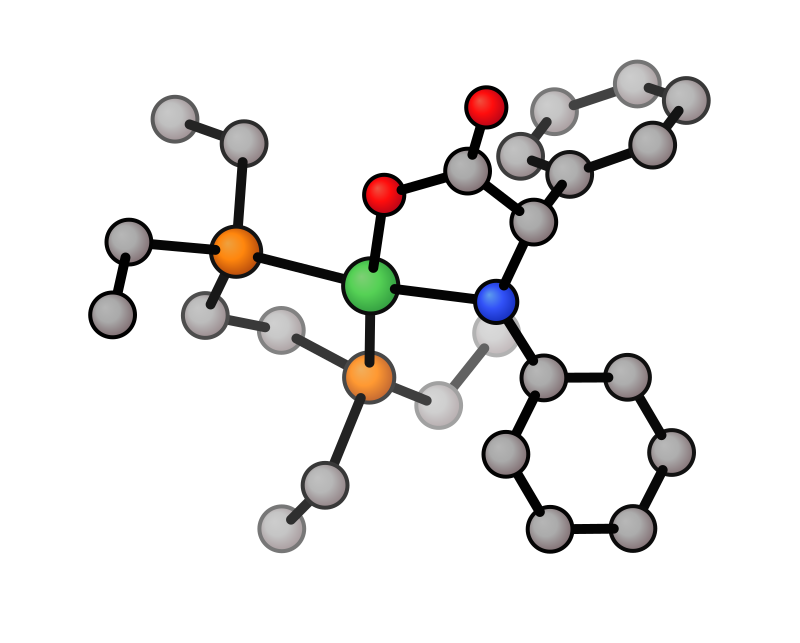

rxembed | embed[square_planar: P7 P2 O13 C23]: 1 seeds


  [0] square_planar    P7 P2 O13 C23              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | P7 P2 O13 C23 | achiral
  M-donor: {'P7': 2.24, 'O13': 2.02, 'P2': 2.24, 'C23': 2.13}  | geom.check: clean


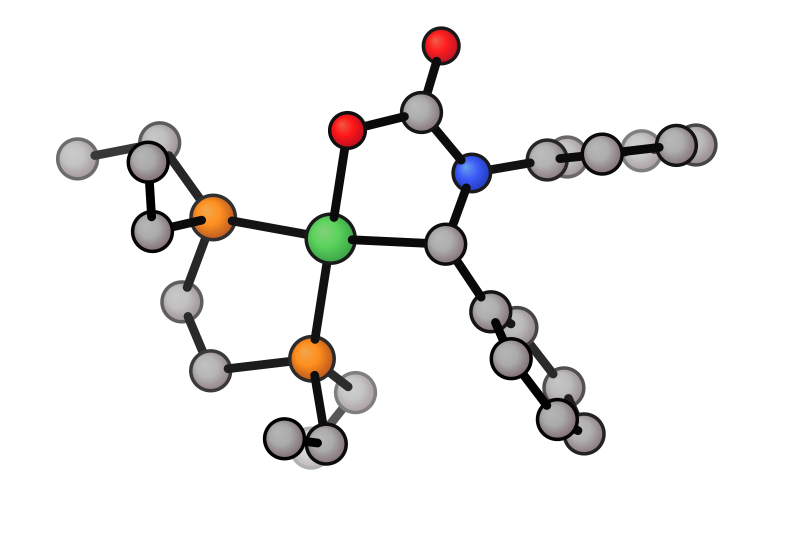

rxembed | embed[square_planar: S6 N1 O8 N18]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    S6 N1 O8 N18               (achiral)
  [1] square_planar    S6 N1 N18 O8               (achiral)
embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 O8 N18 | achiral
  M-donor: {'S6': 2.23, 'O8': 2.01, 'N1': 2.07, 'N18': 2.07}  | geom.check: clean


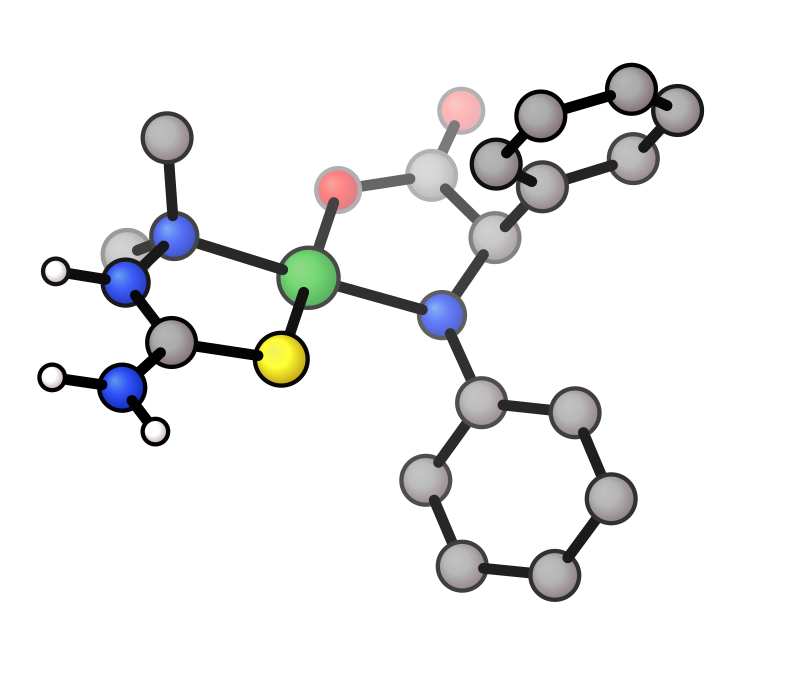

rxembed | embed[square_planar: S6 N1 N18 O8]: 1 seeds
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | S6 N1 N18 O8 | achiral
  M-donor: {'S6': 2.23, 'O8': 2.01, 'N1': 2.07, 'N18': 2.07}  | geom.check: clean


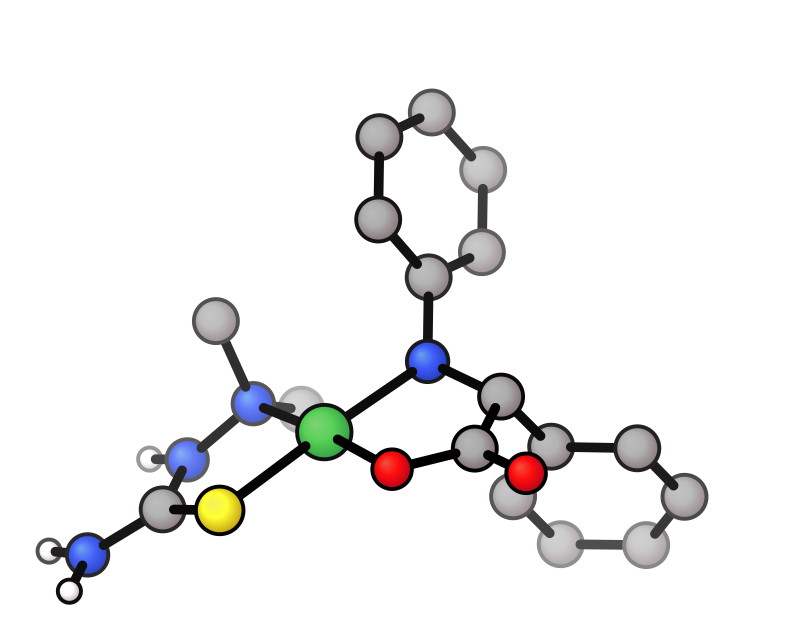

rxembed | embed[square_planar: S6 N1 O8 C18]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04


  [0] square_planar    S6 N1 O8 C18               (achiral)
  [1] square_planar    S6 N1 C18 O8               (achiral)


rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 O8 C18 | achiral
  M-donor: {'S6': 2.23, 'O8': 2.01, 'N1': 2.07, 'C18': 2.13}  | geom.check: clean


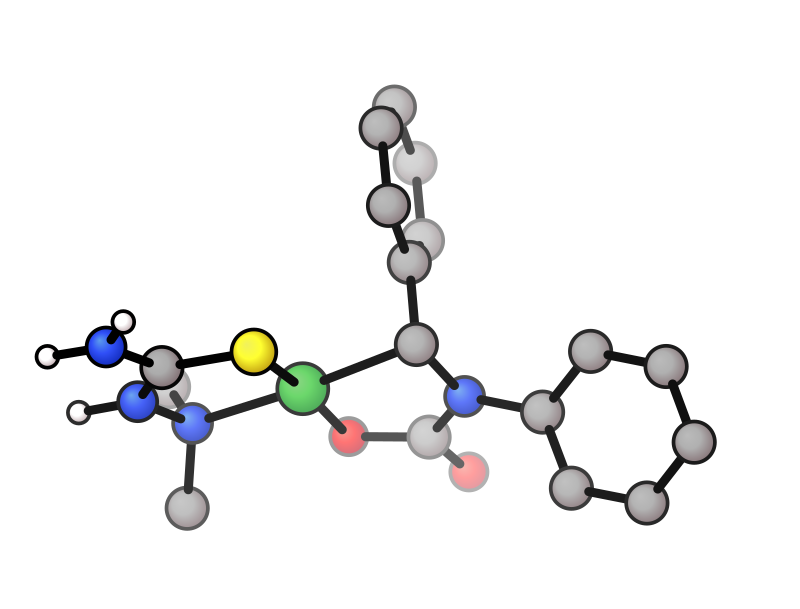

rxembed | embed[square_planar: S6 N1 C18 O8]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
C[N]1(C)NC(N)=[S]->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | S6 N1 C18 O8 | achiral
  M-donor: {'S6': 2.18, 'O8': 1.98, 'N1': 2.03, 'C18': 2.08}  | geom.check: clean


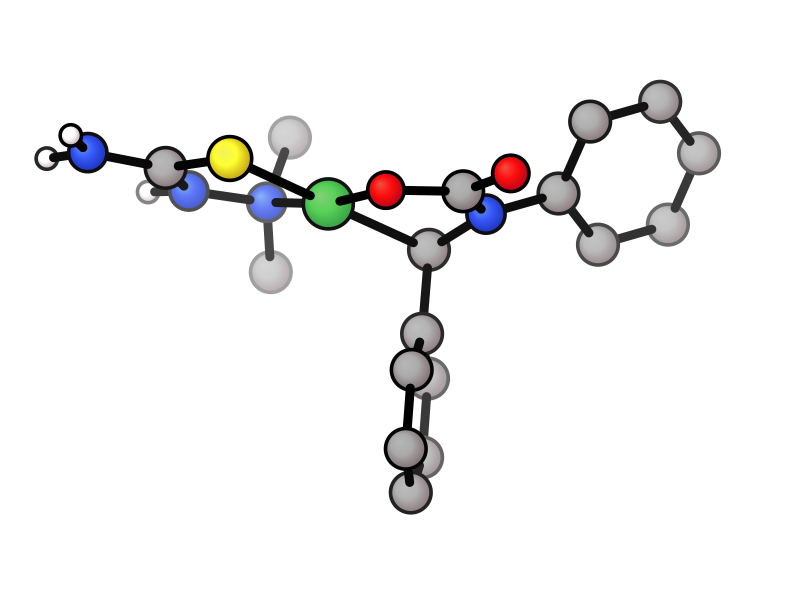

rxembed | embed[square_planar: N4 S25 O8 N18]: 1 seeds


  [0] square_planar    N4 S25 O8 N18              (achiral)
  [1] square_planar    N4 S25 N18 O8              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 N18 | achiral
  M-donor: {'N4': 2.07, 'O8': 2.01, 'S25': 2.23, 'N18': 2.07}  | geom.check: clean


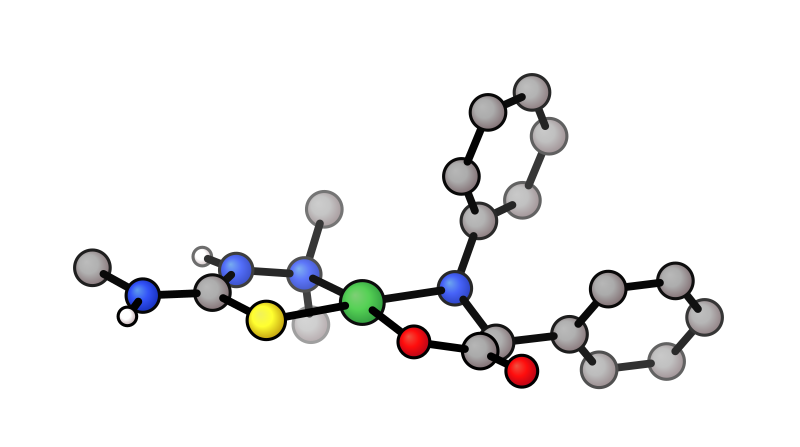

rxembed | embed[square_planar: N4 S25 N18 O8]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 N18 O8 | achiral
  M-donor: {'N4': 2.07, 'O8': 2.01, 'S25': 2.23, 'N18': 2.07}  | geom.check: clean


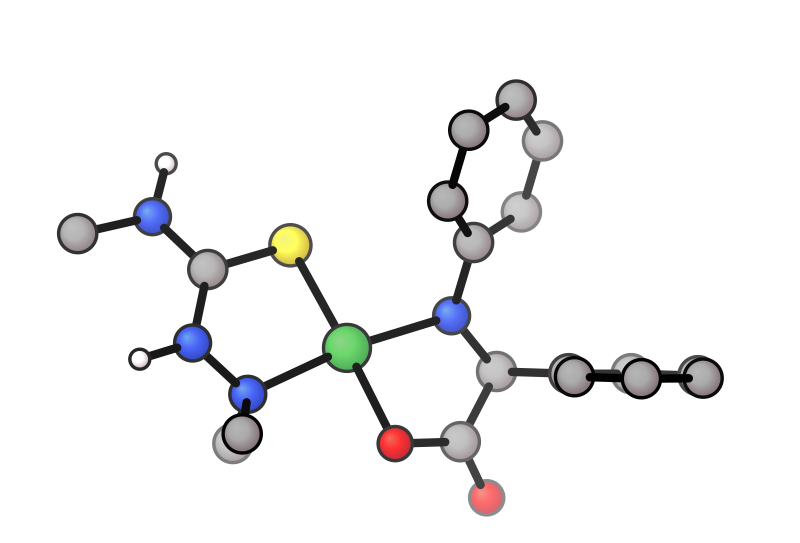

rxembed | embed[square_planar: N4 S25 O8 C18]: 1 seeds


  [0] square_planar    N4 S25 O8 C18              (achiral)
  [1] square_planar    N4 S25 C18 O8              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 O8 C18 | achiral
  M-donor: {'N4': 2.03, 'O8': 1.98, 'S25': 2.18, 'C18': 2.08}  | geom.check: clean


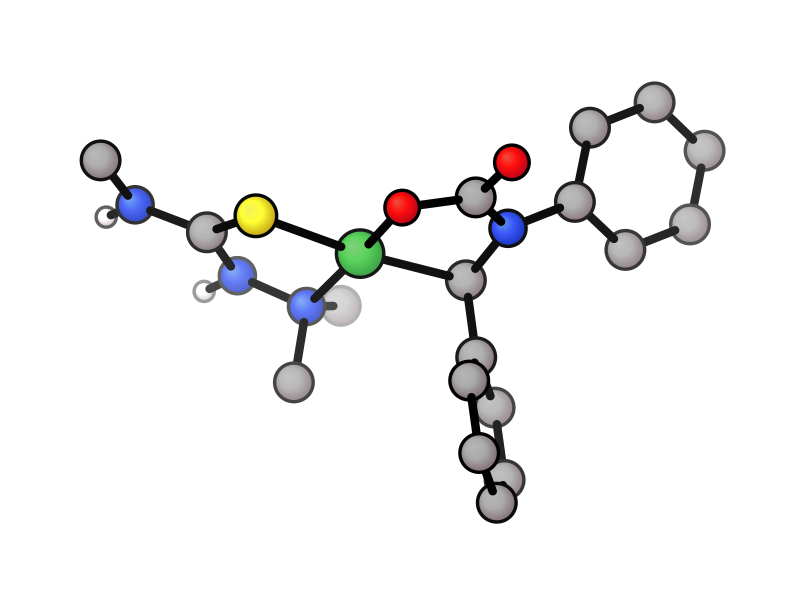

rxembed | embed[square_planar: N4 S25 C18 O8]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CNC1N[N](C)(C)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N4 S25 C18 O8 | achiral
  M-donor: {'N4': 2.07, 'O8': 2.01, 'S25': 2.23, 'C18': 2.13}  | geom.check: clean


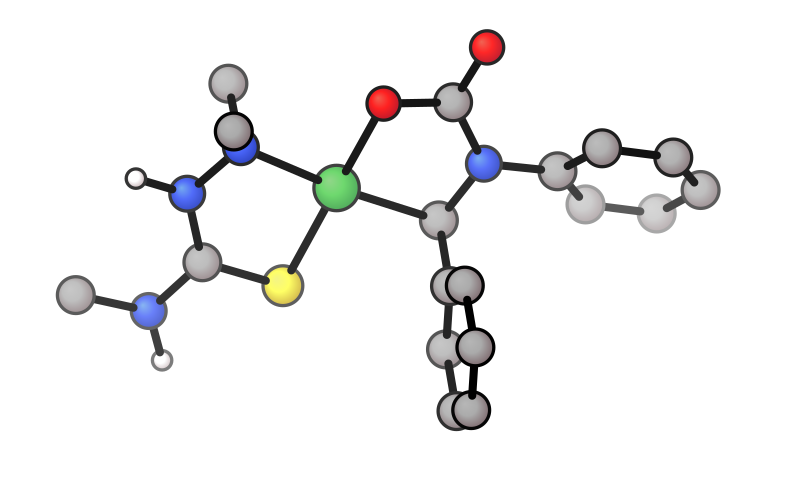

rxembed | embed[square_planar: N5 S24 O7 N17]: 1 seeds


  [0] square_planar    N5 S24 O7 N17              (achiral)
  [1] square_planar    N5 S24 N17 O7              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N5 S24 O7 N17 | achiral
  M-donor: {'N5': 2.06, 'O7': 2.01, 'S24': 2.23, 'N17': 2.07}  | geom.check: clean


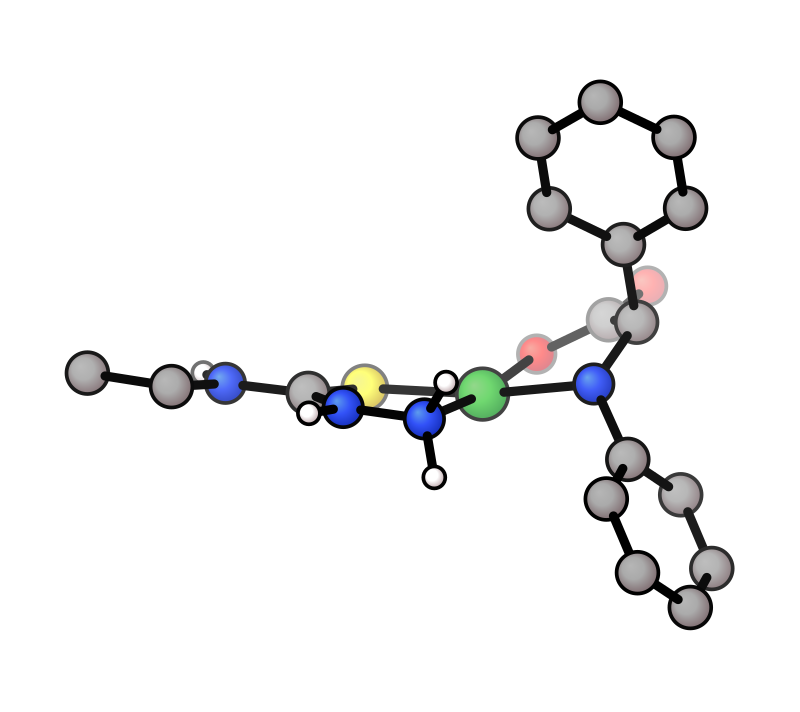

rxembed | embed[square_planar: N5 S24 N17 O7]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[S]=1
 square_planar | N5 S24 N17 O7 | achiral
  M-donor: {'N5': 2.06, 'O7': 2.01, 'S24': 2.23, 'N17': 2.07}  | geom.check: clean


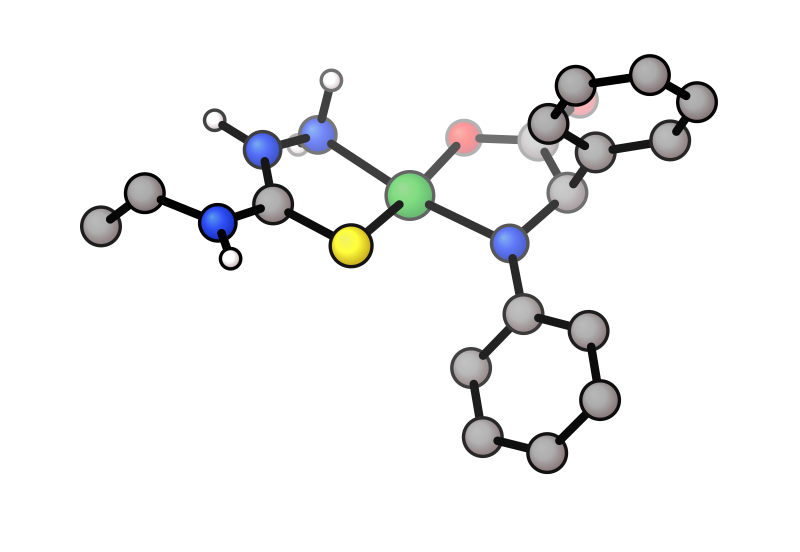

rxembed | embed[square_planar: N5 S24 O7 C17]: 1 seeds


  [0] square_planar    N5 S24 O7 C17              (achiral)
  [1] square_planar    N5 S24 C17 O7              (achiral)


rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


embedding 
CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N5 S24 O7 C17 | achiral
  M-donor: {'N5': 2.06, 'O7': 2.01, 'S24': 2.23, 'C17': 2.13}  | geom.check: clean


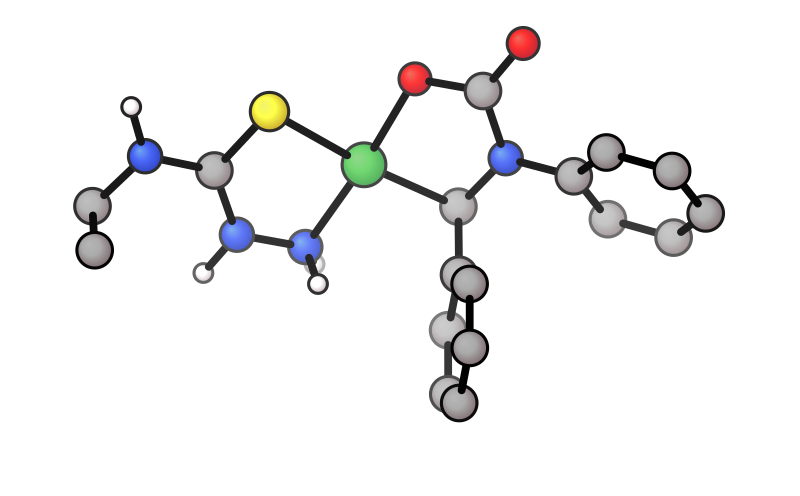

rxembed | embed[square_planar: N5 S24 C17 O7]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCNC1N[NH2]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[S]=1
 square_planar | N5 S24 C17 O7 | achiral
  M-donor: {'N5': 2.06, 'O7': 2.01, 'S24': 2.23, 'C17': 2.13}  | geom.check: clean


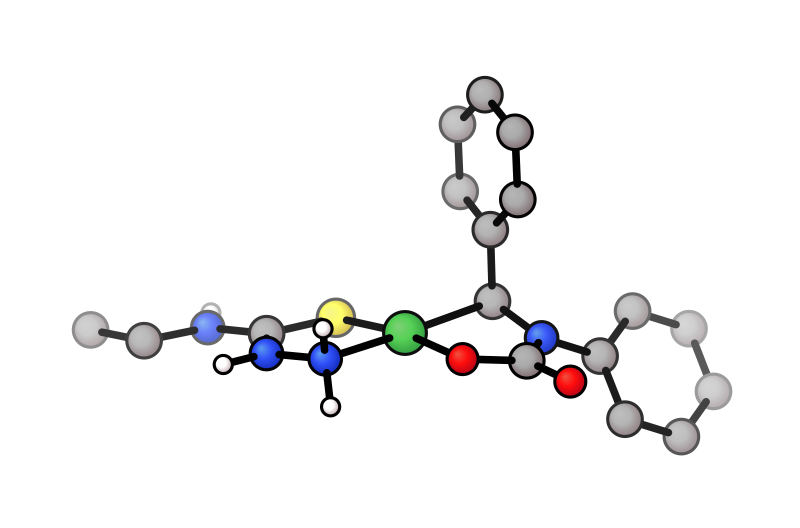

  [0] square_planar    O2 N4 P18 P21              (achiral)


rxembed | embed[square_planar: O2 N4 P18 P21]: 1 seeds
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1
 square_planar | O2 N4 P18 P21 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.07, 'P18': 2.24, 'P21': 2.24}  | geom.check: clean


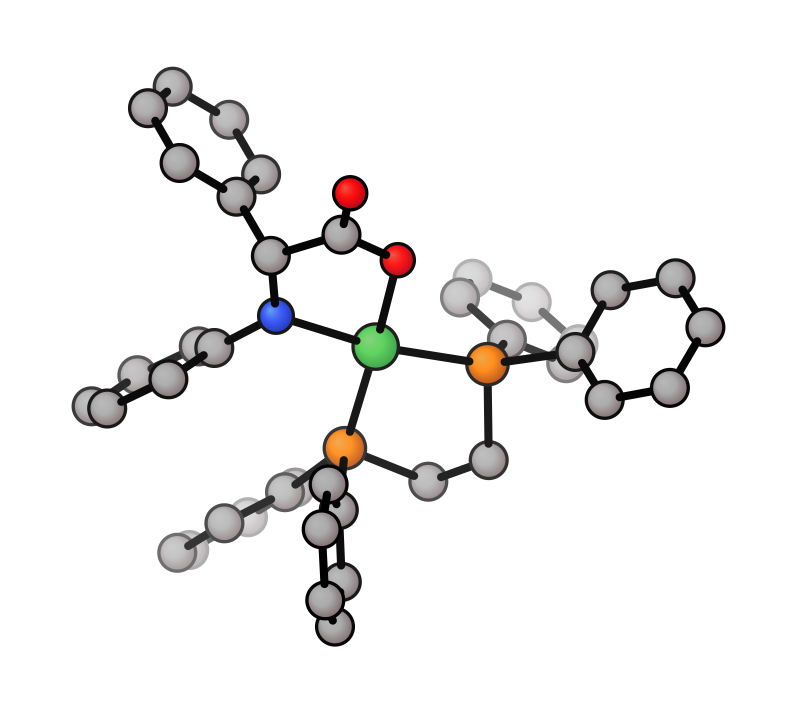

rxembed | embed[square_planar: O2 C4 P18 P21]: 1 seeds


  [0] square_planar    O2 C4 P18 P21              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](CC[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1
 square_planar | O2 C4 P18 P21 | achiral
  M-donor: {'O2': 1.95, 'C4': 2.05, 'P18': 2.15, 'P21': 2.15}  | geom.check: clean


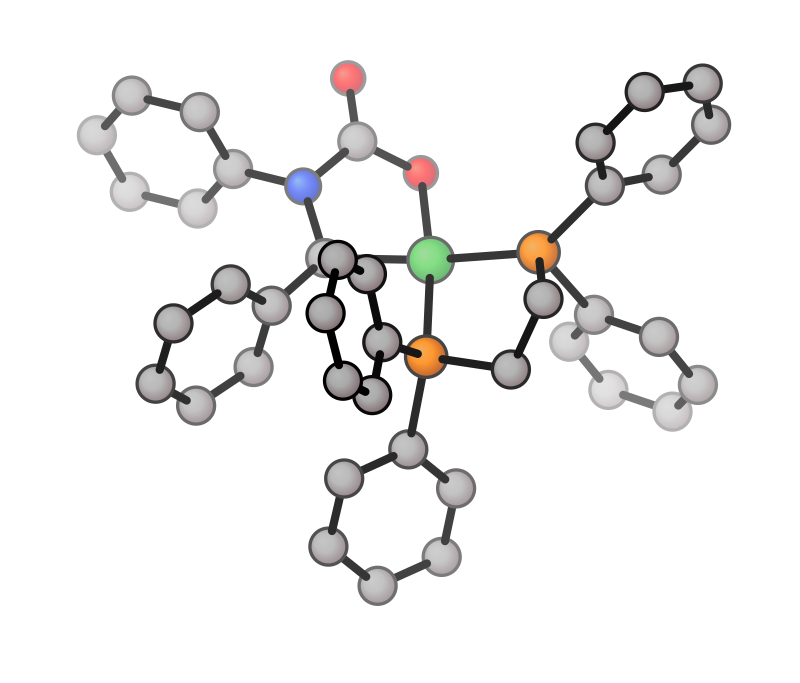

rxembed | embed[square_planar: O2 N19 N4 N18]: 1 seeds


  [0] square_planar    O2 N19 N4 N18              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N](O)=C(c3ccccn3)c3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N19 N4 N18 | achiral
  M-donor: {'O2': 1.95, 'N4': 2.0, 'N19': 2.0, 'N18': 2.0}  | geom.check: clean


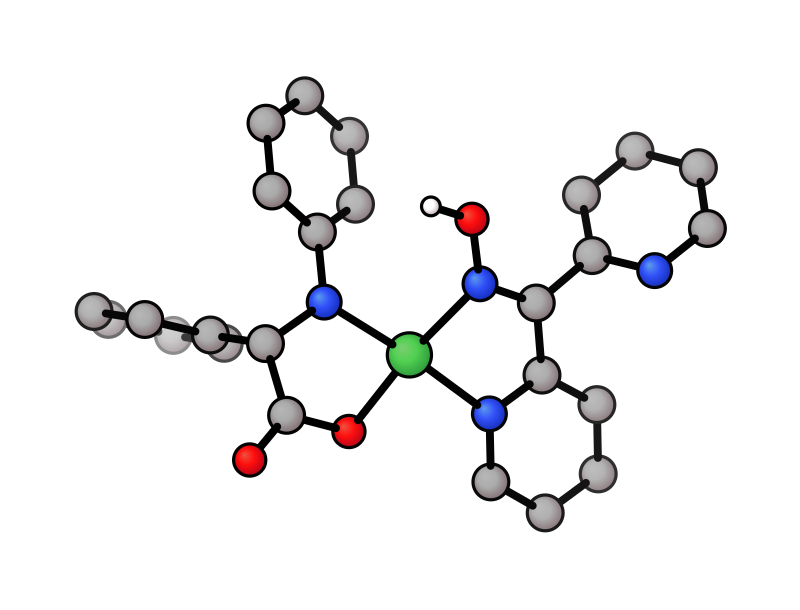

rxembed | embed[square_planar: O2 C4 N18 N32]: 1 seeds


  [0] square_planar    O2 C4 N18 N32              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](O)=C(c1ccccn1)c1cccc[n]->21
 square_planar | O2 C4 N18 N32 | achiral
  M-donor: {'O2': 2.01, 'C4': 2.13, 'N18': 2.07, 'N32': 2.07}  | geom.check: clean


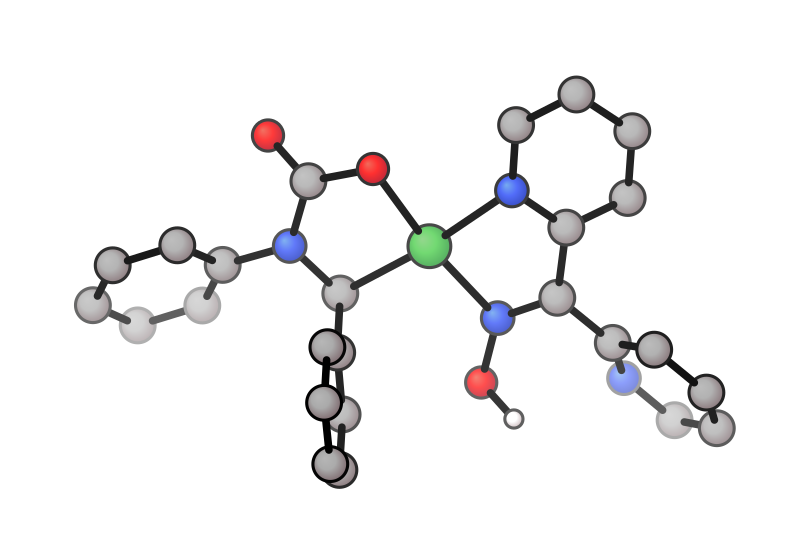

rxembed | embed[square_planar: O2 N18 N4 N15]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 N18 N4 N15              (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[n]3cccc4ccc5ccc[n]->2c5c43)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N18 N4 N15 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.07, 'N18': 2.07, 'N15': 2.07}  | geom.check: clean


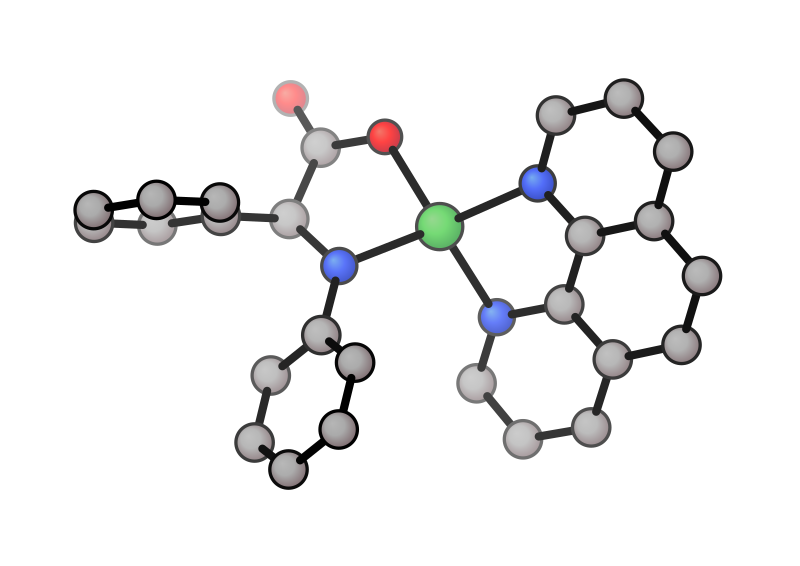

  [0] square_planar    O2 C4 N18 N29              (achiral)


rxembed | embed[square_planar: O2 C4 N18 N29]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1cccc3ccc4ccc[n]->2c4c31
 square_planar | O2 C4 N18 N29 | achiral
  M-donor: {'O2': 2.01, 'C4': 2.13, 'N18': 2.07, 'N29': 2.07}  | geom.check: clean


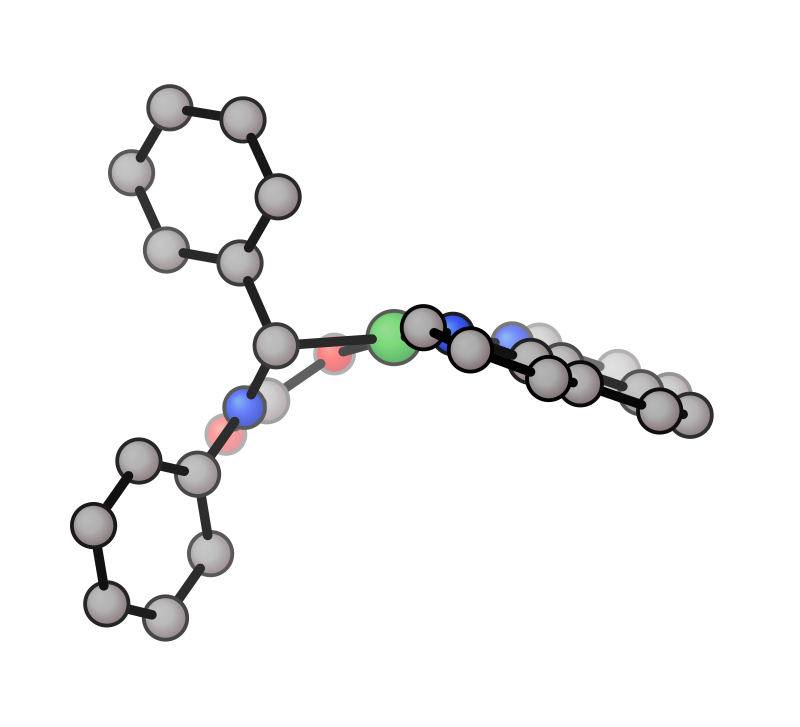

  [0] square_planar    N8 N27 O10 N20             (achiral)


rxembed | embed[square_planar: N8 N27 O10 N20]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[n]4cccc1c4-c23
 square_planar | N8 N27 O10 N20 | achiral
  M-donor: {'N8': 2.07, 'O10': 2.01, 'N27': 2.07, 'N20': 2.07}  | geom.check: clean


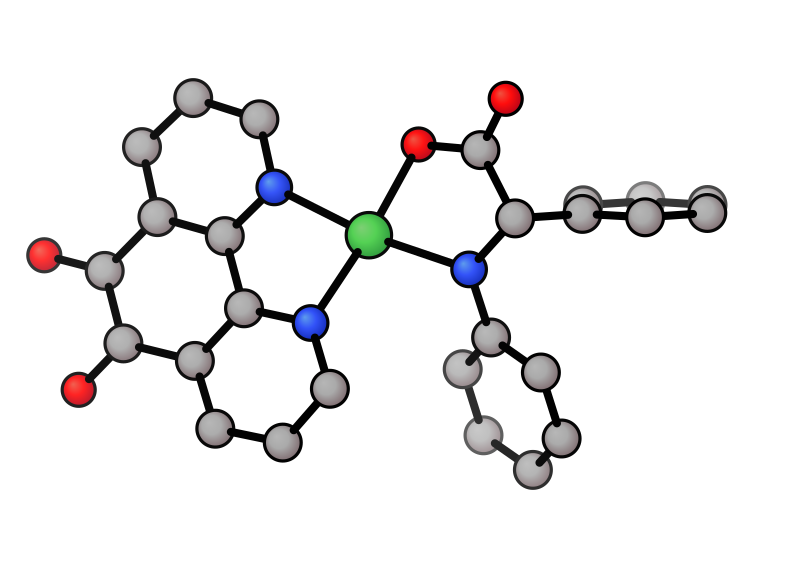

  [0] square_planar    N8 N27 O10 C20             (achiral)


rxembed | embed[square_planar: N8 N27 O10 C20]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1C(=O)c2ccc[n]3->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[n]4cccc1c4-c23
 square_planar | N8 N27 O10 C20 | achiral
  M-donor: {'N8': 2.01, 'O10': 1.96, 'N27': 2.01, 'C20': 2.06}  | geom.check: clean


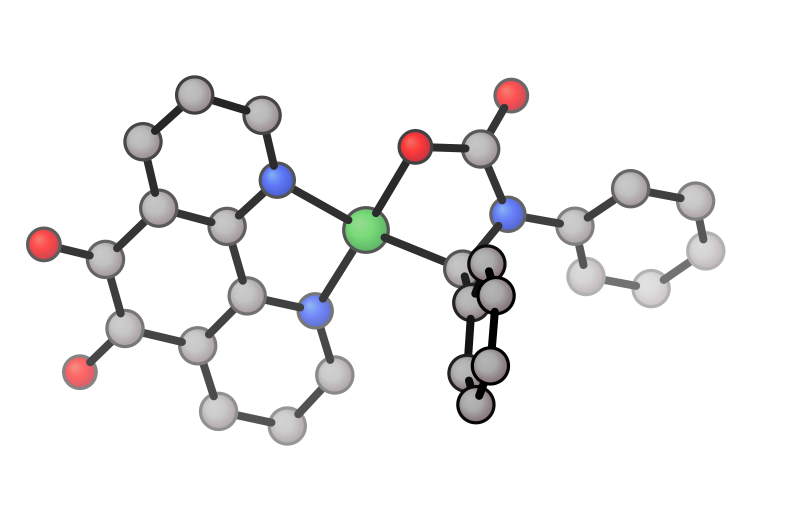

rxembed | embed[square_planar: O2 N21 N4 N20]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04


  [0] square_planar    O2 N21 N4 N20              (achiral)


rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[n]3ccccc3-c3cn(C4CCCCC4)n[n]->23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N21 N4 N20 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.07, 'N21': 2.07, 'N20': 2.07}  | geom.check: clean


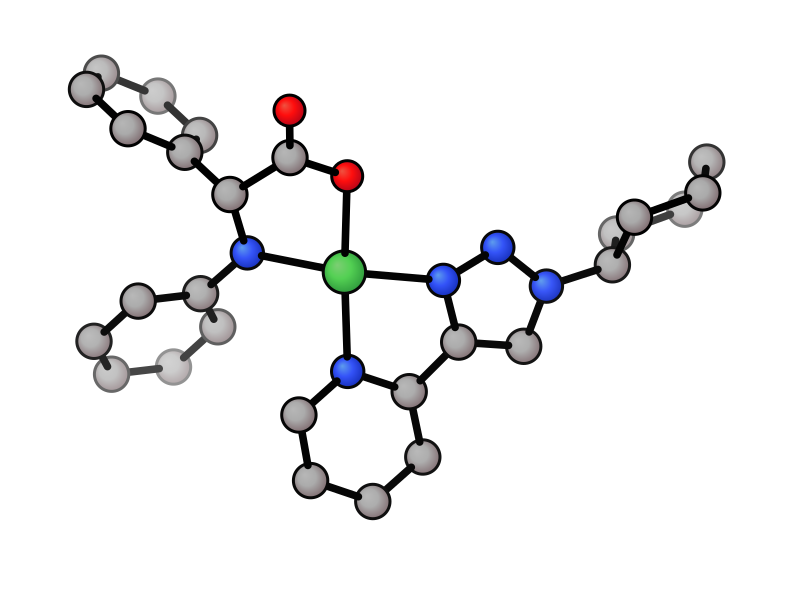

rxembed | embed[square_planar: O2 C4 N18 N34]: 1 seeds


  [0] square_planar    O2 C4 N18 N34              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[n]1ccccc1-c1cn(C3CCCCC3)n[n]->21
 square_planar | O2 C4 N18 N34 | achiral
  M-donor: {'O2': 1.98, 'C4': 2.08, 'N18': 2.03, 'N34': 2.03}  | geom.check: clean


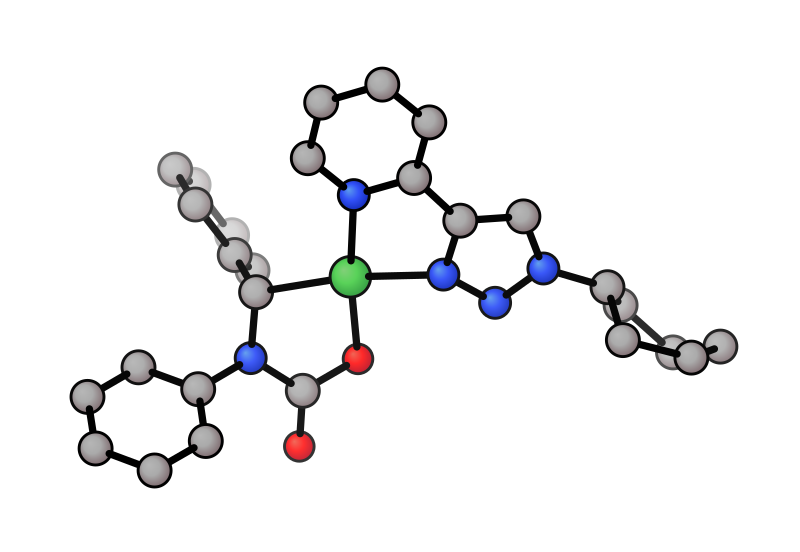

rxembed | embed[square_planar: P6 P3 O14 N24]: 1 seeds


  [0] square_planar    P6 P3 O14 N24              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1)C(C)C
 square_planar | P6 P3 O14 N24 | achiral
  M-donor: {'P6': 2.24, 'O14': 2.01, 'P3': 2.24, 'N24': 2.07}  | geom.check: clean


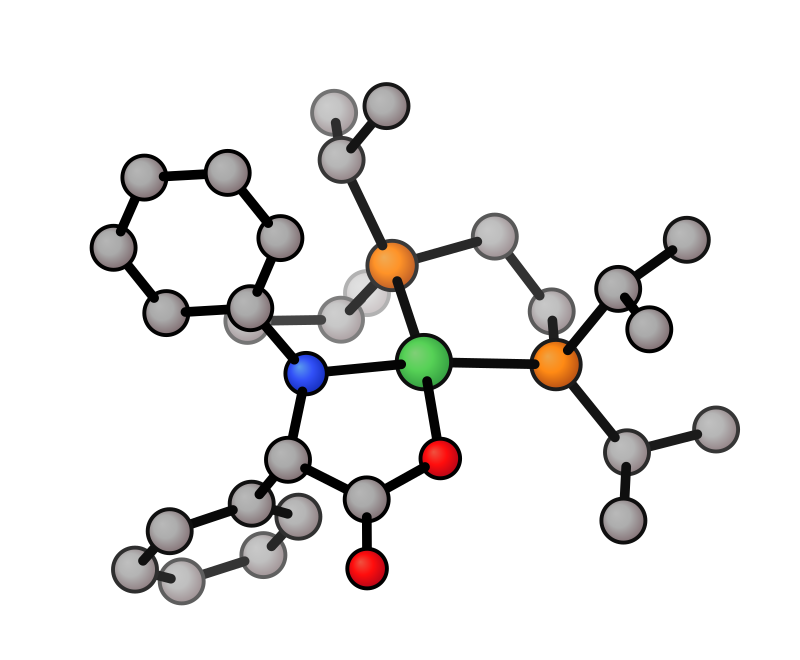

rxembed | embed[square_planar: P6 P3 O14 C24]: 1 seeds


  [0] square_planar    P6 P3 O14 C24              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC(C)[P]1(CC[P](C(C)C)(C(C)C)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1)C(C)C
 square_planar | P6 P3 O14 C24 | achiral
  M-donor: {'P6': 2.24, 'O14': 2.01, 'P3': 2.24, 'C24': 2.13}  | geom.check: clean


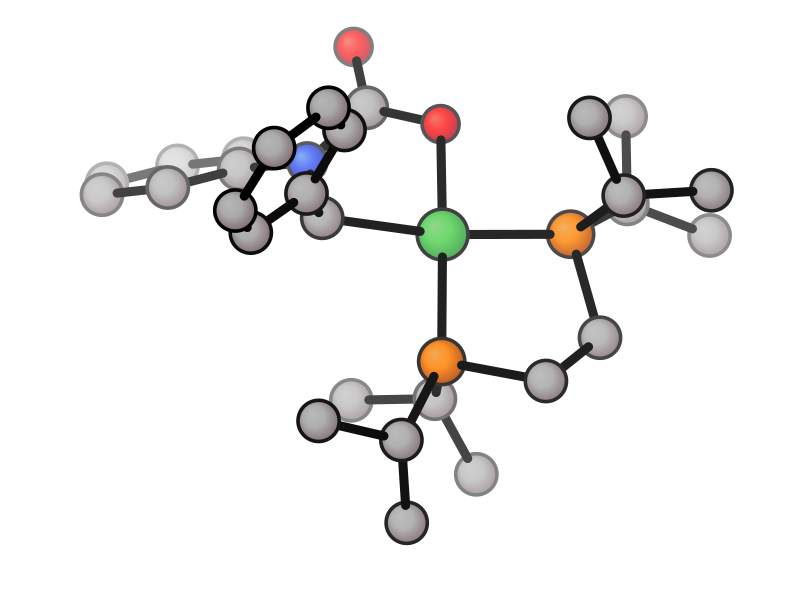

  [0] square_planar    P10 P29 O12 N22            (achiral)


rxembed | embed[square_planar: P10 P29 O12 N22]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1
 square_planar | P10 P29 O12 N22 | achiral
  M-donor: {'P10': 2.24, 'O12': 2.01, 'P29': 2.24, 'N22': 2.07}  | geom.check: clean


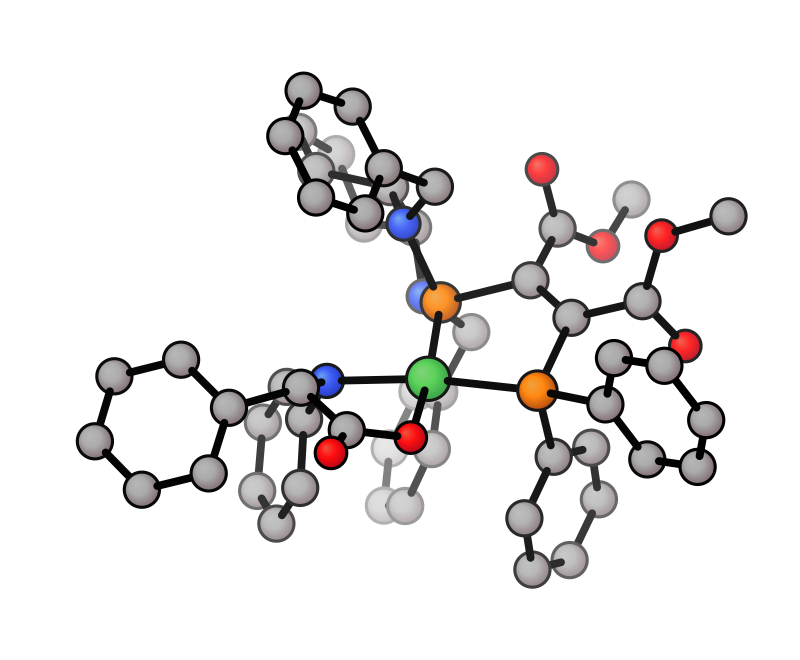

  [0] square_planar    P10 P29 O12 C22            (achiral)


rxembed | embed[square_planar: P10 P29 O12 C22]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
COC(=O)C1=C(C(=O)OC)[P]2(->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[P]1(c1ccccc1)c1ccccc1)N(Cc1ccccc1)C1CCCCC1N2Cc1ccccc1
 square_planar | P10 P29 O12 C22 | achiral
  M-donor: {'P10': 2.24, 'O12': 2.01, 'P29': 2.24, 'C22': 2.13}  | geom.check: clean


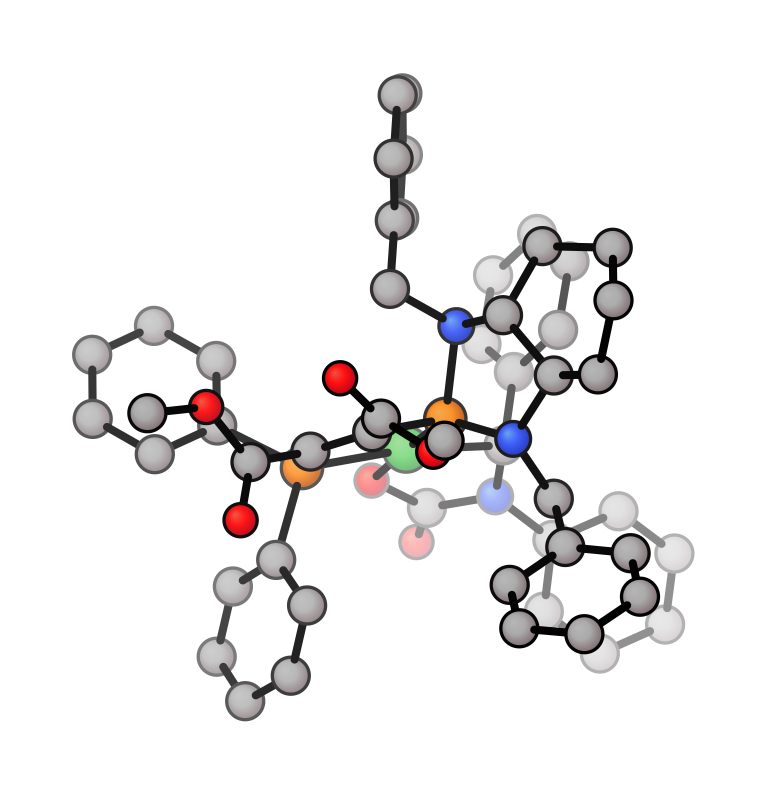

rxembed | embed[square_planar: N15 N34 O17 N27]: 1 seeds


  [0] square_planar    N15 N34 O17 N27            (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C
 square_planar | N15 N34 O17 N27 | achiral
  M-donor: {'N15': 2.07, 'O17': 2.01, 'N34': 2.07, 'N27': 2.07}  | geom.check: clean


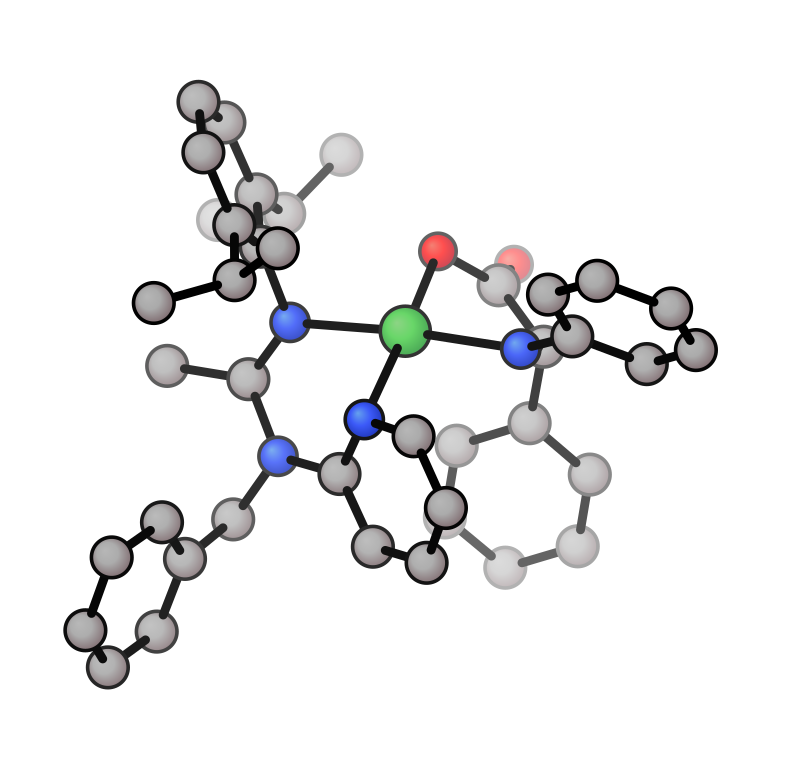

  [0] square_planar    N15 N34 O17 C27            (achiral)


rxembed | embed[square_planar: N15 N34 O17 C27]: 1 seeds
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1N(Cc2ccccc2)c2cccc[n]2->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1c1c(C(C)C)cccc1C(C)C
 square_planar | N15 N34 O17 C27 | achiral
  M-donor: {'N15': 2.07, 'O17': 2.01, 'N34': 2.07, 'C27': 2.13}  | geom.check: clean


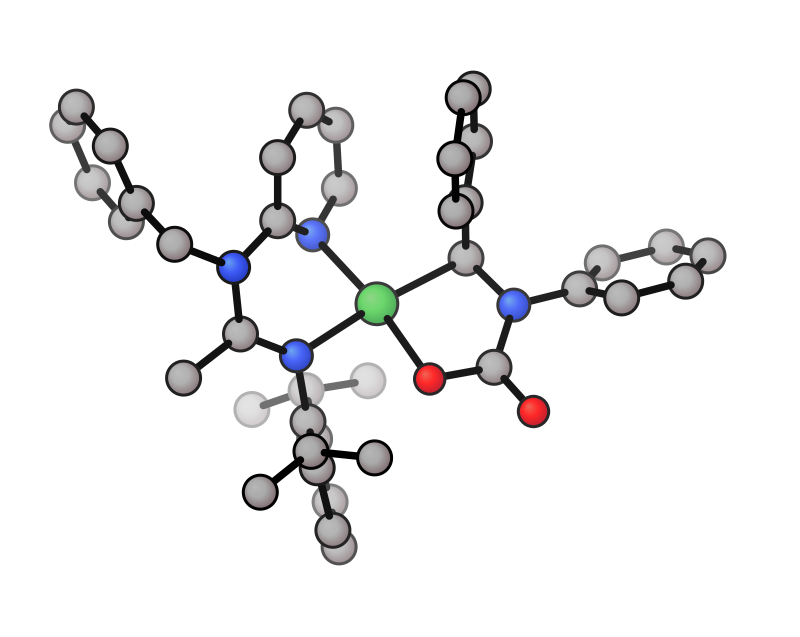

rxembed | embed[square_planar: O5 O7 O8 N18]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O5 O7 O8 N18               (achiral)
embedding 
CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | O5 O7 O8 N18 | achiral
  M-donor: {'O5': 1.96, 'O7': 1.96, 'O8': 1.96, 'N18': 2.01}  | geom.check: clean


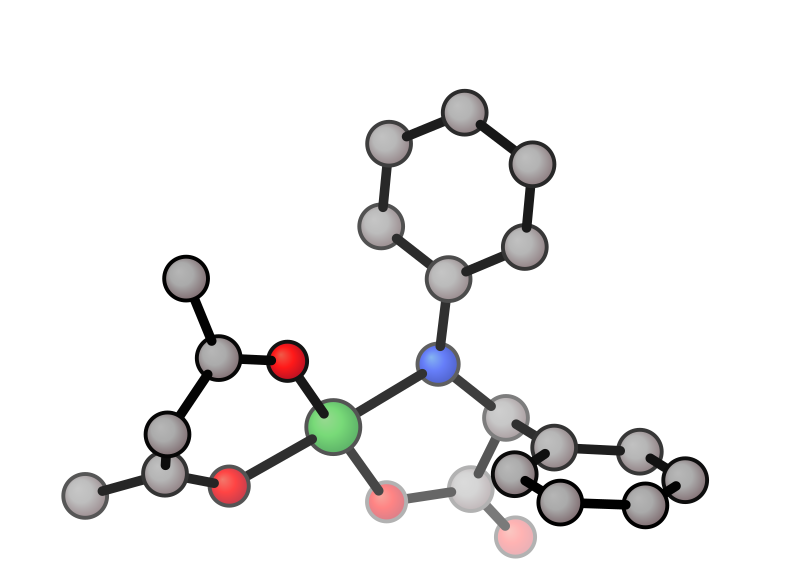

rxembed | embed[square_planar: O5 O7 O8 C18]: 1 seeds


  [0] square_planar    O5 O7 O8 C18               (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1CC(C)=[O]->[Ni+2]2(<-[O]=1)<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | O5 O7 O8 C18 | achiral
  M-donor: {'O5': 2.01, 'O7': 2.01, 'O8': 2.01, 'C18': 2.13}  | geom.check: clean


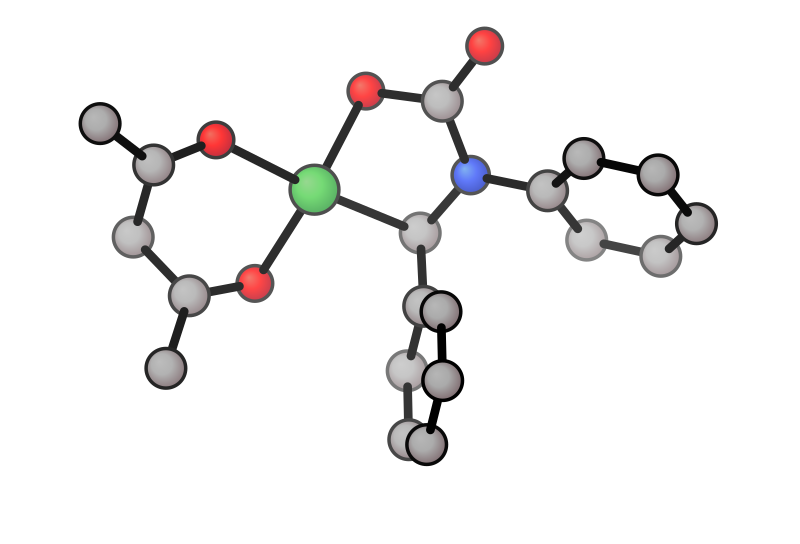

rxembed | embed[square_planar: O4 N23 O6 N16]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O4 N23 O6 N16              (achiral)
  [1] square_planar    O4 N23 N16 O6              (achiral)
embedding 
CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[n]2c[nH]c(C)c21
 square_planar | O4 N23 O6 N16 | achiral
  M-donor: {'O4': 2.01, 'O6': 2.01, 'N23': 2.07, 'N16': 2.06}  | geom.check: clean


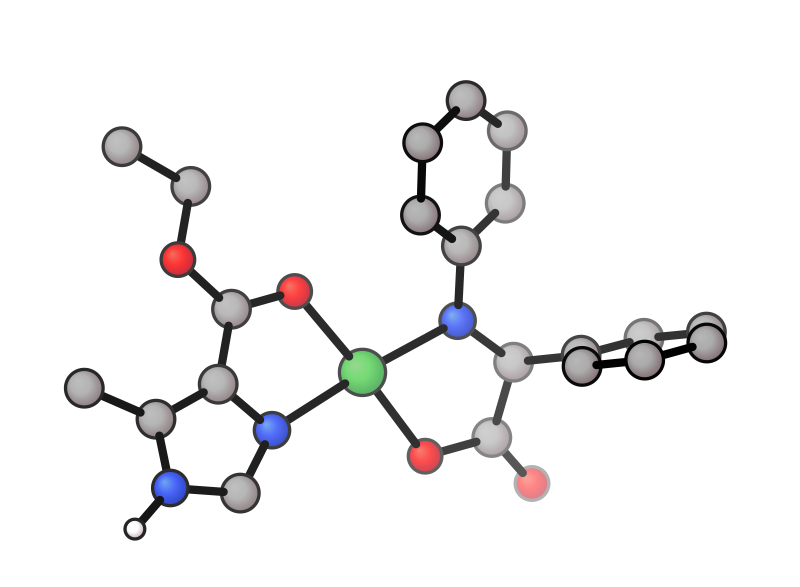

rxembed | embed[square_planar: O4 N23 N16 O6]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[n]2c[nH]c(C)c21
 square_planar | O4 N23 N16 O6 | achiral
  M-donor: {'O4': 1.96, 'O6': 1.96, 'N23': 2.01, 'N16': 2.01}  | geom.check: clean


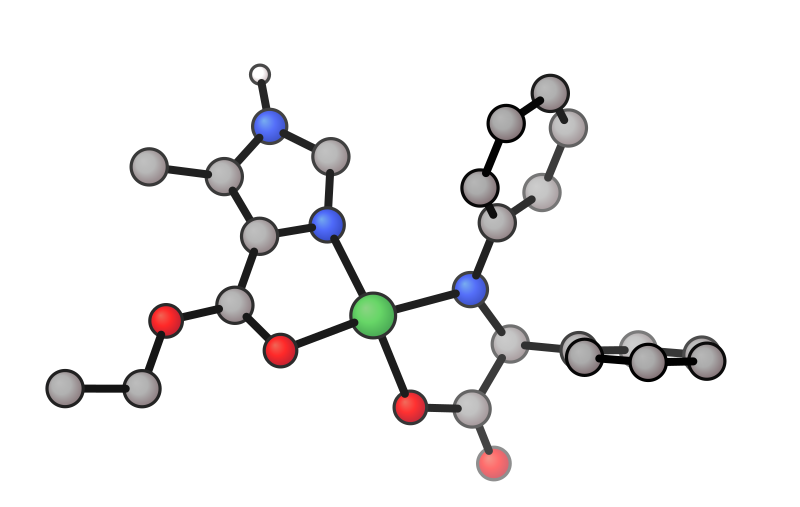

rxembed | embed[square_planar: O4 N23 O6 C16]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O4 N23 O6 C16              (achiral)
  [1] square_planar    O4 N23 C16 O6              (achiral)
embedding 
CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[n]2c[nH]c(C)c21
 square_planar | O4 N23 O6 C16 | achiral
  M-donor: {'O4': 2.01, 'O6': 2.01, 'N23': 2.07, 'C16': 2.13}  | geom.check: clean


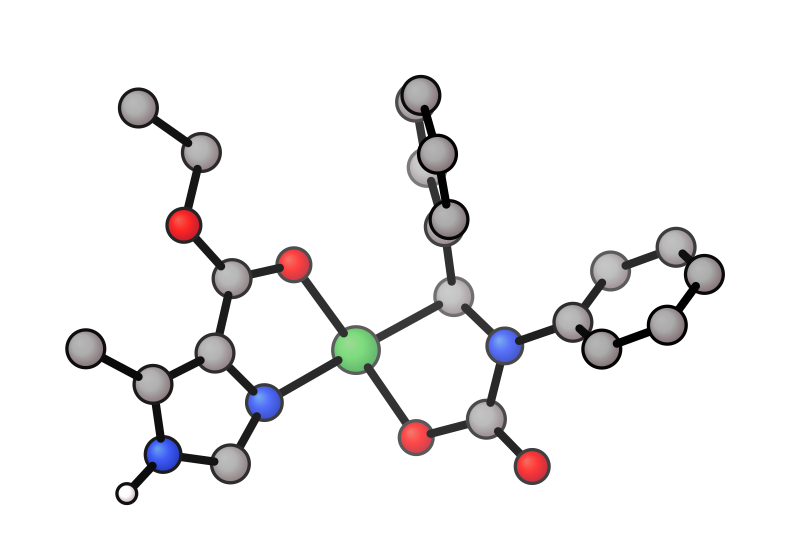

rxembed | embed[square_planar: O4 N23 C16 O6]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCOC1=[O]->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[n]2c[nH]c(C)c21
 square_planar | O4 N23 C16 O6 | achiral
  M-donor: {'O4': 1.98, 'O6': 1.98, 'N23': 2.03, 'C16': 2.09}  | geom.check: clean


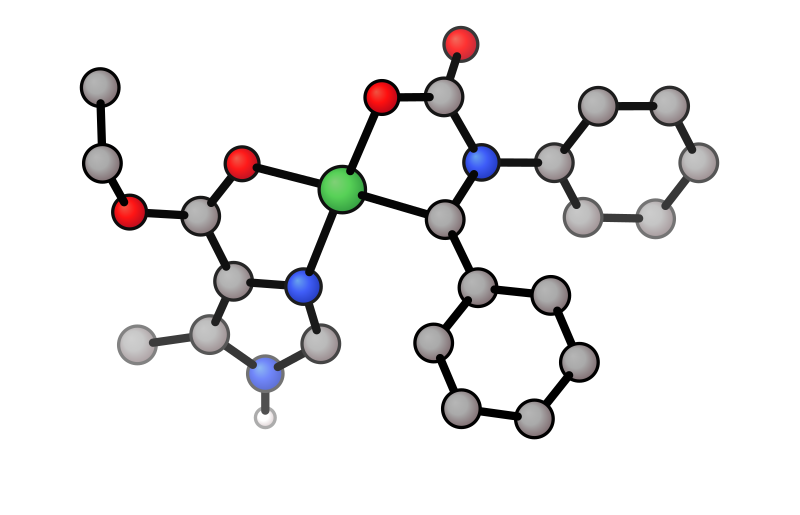

rxembed | embed[square_planar: P7 P2 O21 N31]: 1 seeds


  [0] square_planar    P7 P2 O21 N31              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1
 square_planar | P7 P2 O21 N31 | achiral
  M-donor: {'P7': 2.16, 'O21': 1.96, 'P2': 2.16, 'N31': 2.01}  | geom.check: clean


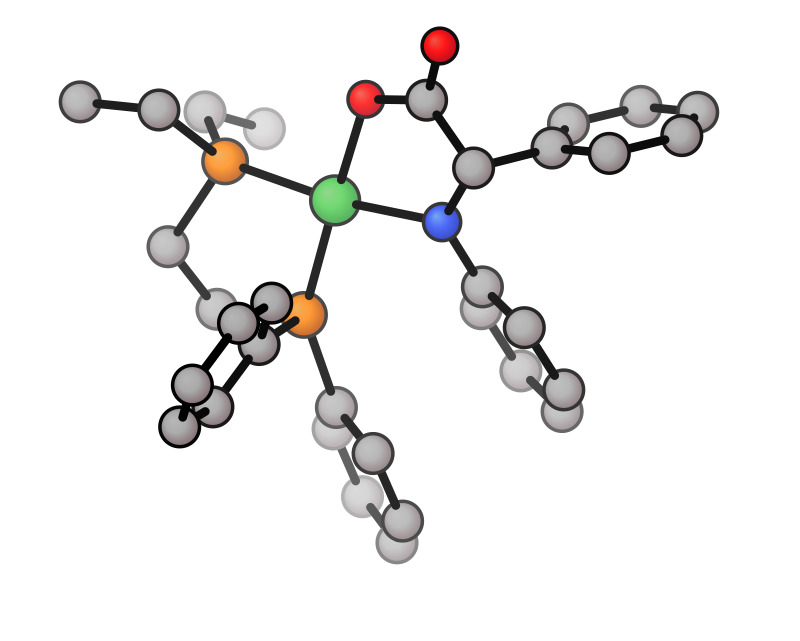

rxembed | embed[square_planar: P7 P2 O21 C31]: 1 seeds


  [0] square_planar    P7 P2 O21 C31              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC[P]1(CC)CC[P](c2ccccc2)(c2ccccc2)->[Ni+2]<-12<-[O-]C(=O)N(c1ccccc1)[CH-]->2c1ccccc1
 square_planar | P7 P2 O21 C31 | achiral
  M-donor: {'P7': 2.24, 'O21': 2.02, 'P2': 2.24, 'C31': 2.13}  | geom.check: clean


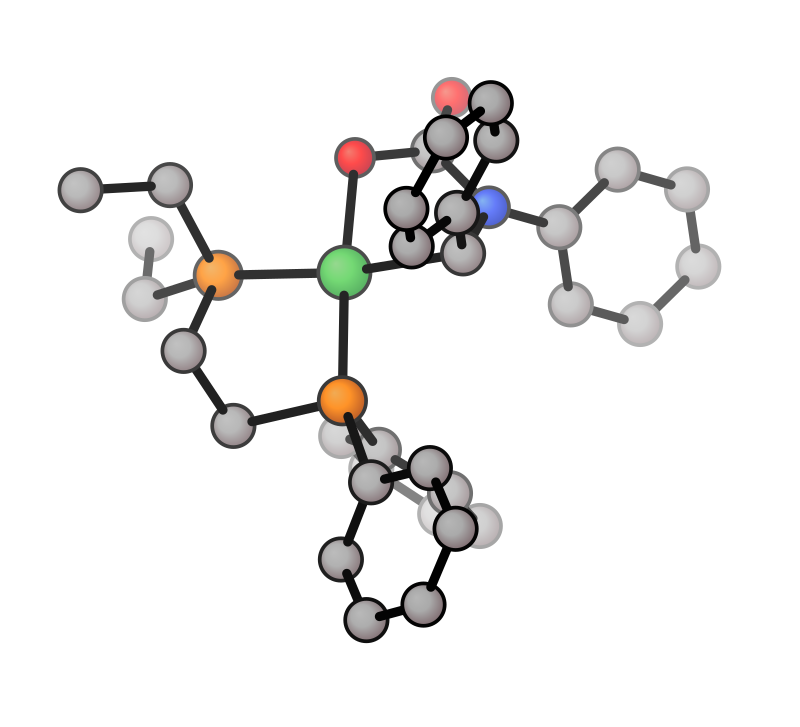

rxembed | embed[square_planar: O2 N32 N4 N19]: 1 seeds


  [0] square_planar    O2 N32 N4 N19              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+05
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N](=CC=Cc3ccccc3[N+](=O)[O-])CC[N]->2=CC=Cc2ccccc2[N+](=O)[O-])<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N32 N4 N19 | achiral
  M-donor: {'O2': 1.95, 'N4': 2.0, 'N32': 2.0, 'N19': 2.0}  | geom.check: clean


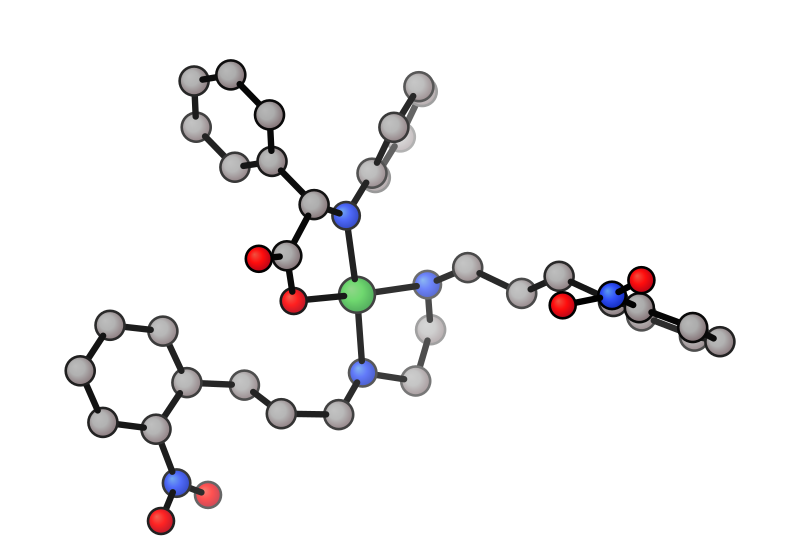

rxembed | embed[square_planar: O2 C4 N18 N33]: 1 seeds


  [0] square_planar    O2 C4 N18 N33              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=CC=Cc1ccccc1[N+](=O)[O-])CC[N]->2=CC=Cc1ccccc1[N+](=O)[O-]
 square_planar | O2 C4 N18 N33 | achiral
  M-donor: {'O2': 2.01, 'C4': 2.13, 'N18': 2.07, 'N33': 2.07}  | geom.check: clean


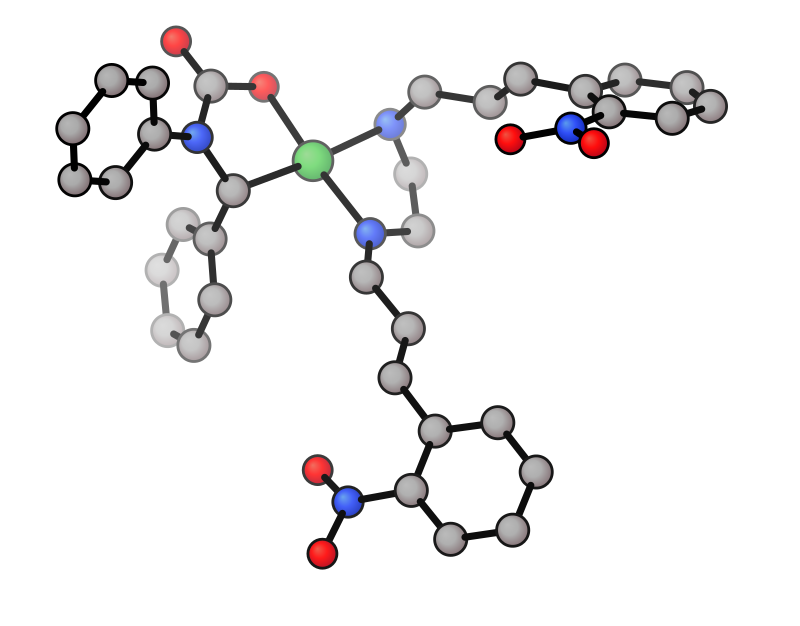

rxembed | embed[square_planar: O2 N4 P18 P21]: 1 seeds


  [0] square_planar    O2 N4 P18 P21              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1
 square_planar | O2 N4 P18 P21 | achiral
  M-donor: {'O2': 1.98, 'N4': 2.03, 'P18': 2.19, 'P21': 2.19}  | geom.check: clean


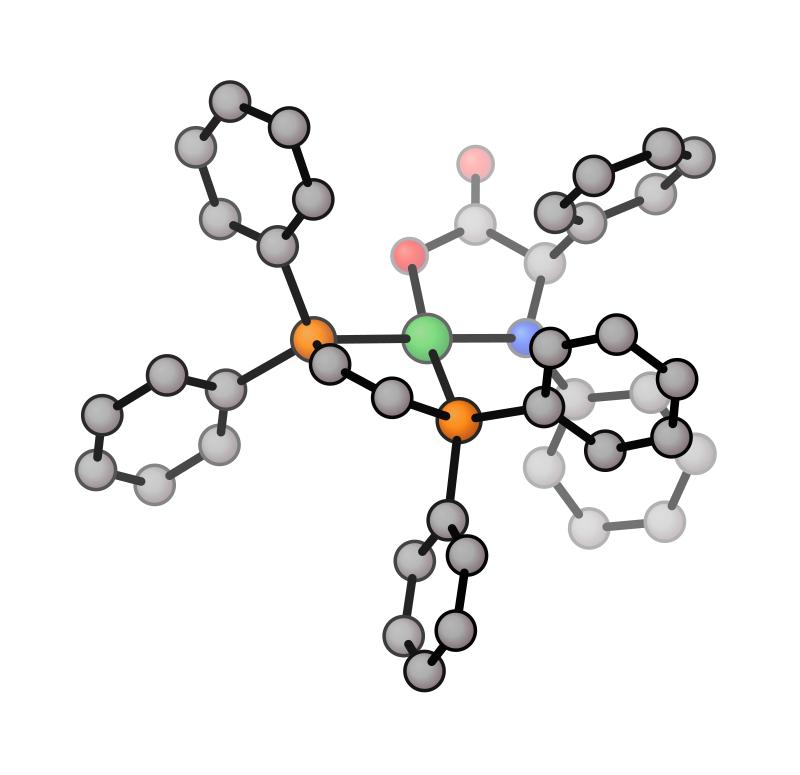

rxembed | embed[square_planar: O2 C4 P18 P21]: 1 seeds


  [0] square_planar    O2 C4 P18 P21              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](C=C[P]->2(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1
 square_planar | O2 C4 P18 P21 | achiral
  M-donor: {'O2': 1.98, 'C4': 2.08, 'P18': 2.19, 'P21': 2.19}  | geom.check: clean


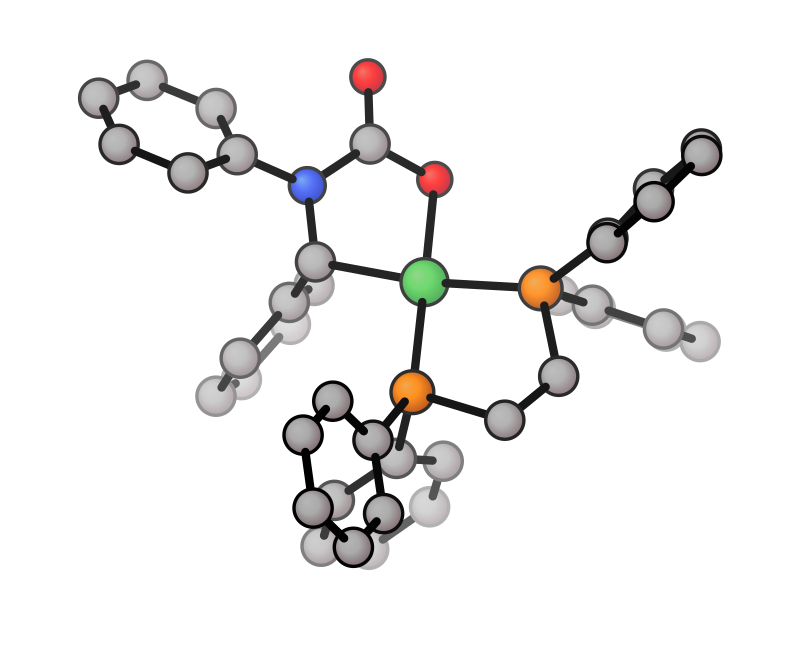

rxembed | embed[square_planar: N16 N35 O18 N28]: 1 seeds


  [0] square_planar    N16 N35 O18 N28            (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12
 square_planar | N16 N35 O18 N28 | achiral
  M-donor: {'N16': 2.06, 'O18': 2.01, 'N35': 2.07, 'N28': 2.07}  | geom.check: clean


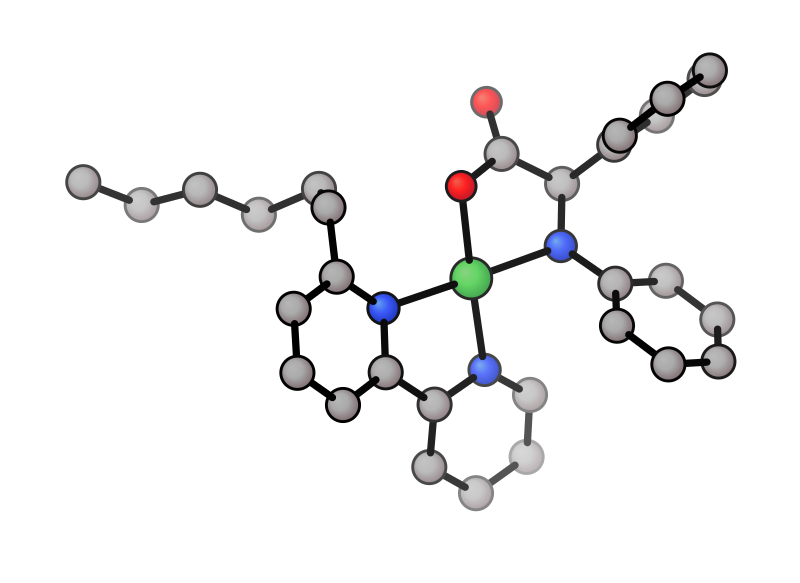

rxembed | embed[square_planar: N16 N35 O18 C28]: 1 seeds


  [0] square_planar    N16 N35 O18 C28            (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCCCCCc1cccc2-c3cccc[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12
 square_planar | N16 N35 O18 C28 | achiral
  M-donor: {'N16': 2.07, 'O18': 2.01, 'N35': 2.07, 'C28': 2.13}  | geom.check: clean


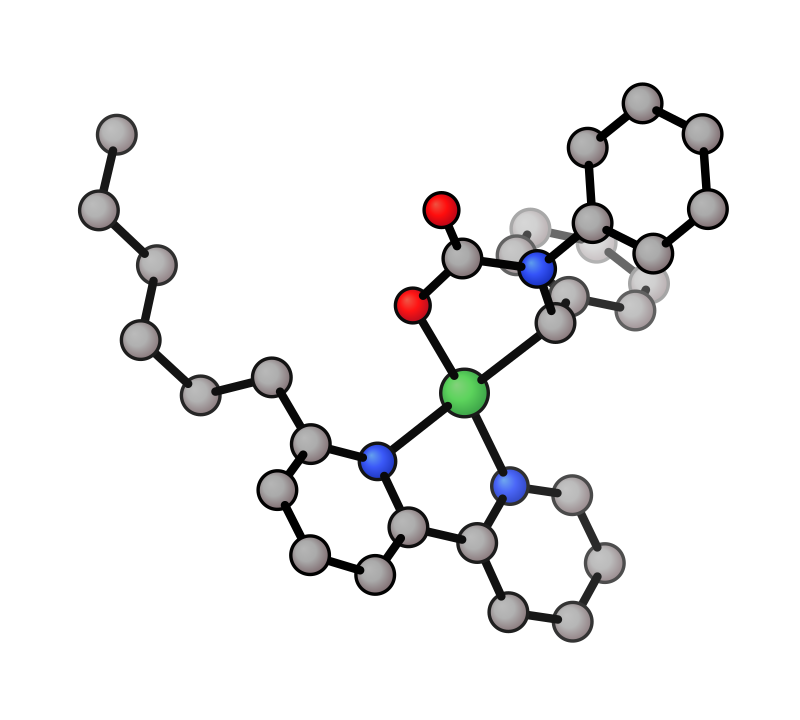

rxembed | embed[square_planar: N24 N43 O26 N36]: 1 seeds


  [0] square_planar    N24 N43 O26 N36            (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]12
 square_planar | N24 N43 O26 N36 | achiral
  M-donor: {'N24': 2.03, 'O26': 1.98, 'N43': 2.03, 'N36': 2.03}  | geom.check: clean


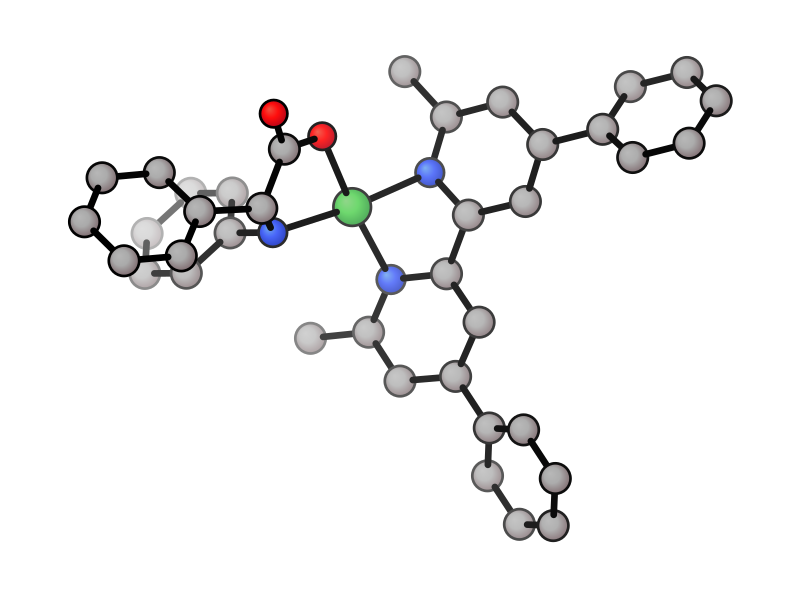

rxembed | embed[square_planar: N24 N43 O26 C36]: 1 seeds


  [0] square_planar    N24 N43 O26 C36            (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(-c2ccccc2)cc2-c3cc(-c4ccccc4)cc(C)[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]12
 square_planar | N24 N43 O26 C36 | achiral
  M-donor: {'N24': 2.07, 'O26': 2.01, 'N43': 2.07, 'C36': 2.13}  | geom.check: clean


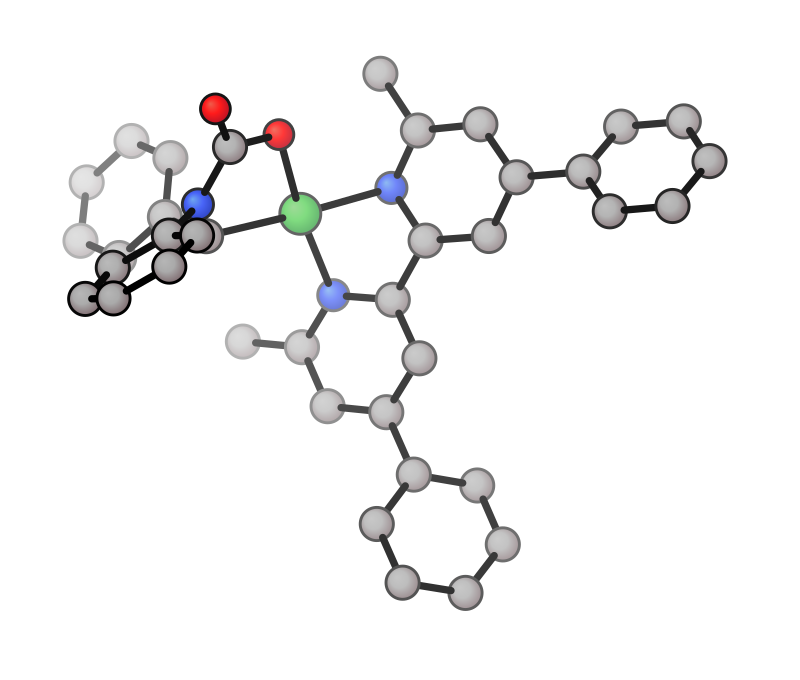

rxembed | embed[square_planar: O2 N8 N4 N7]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 N8 N4 N7                (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N8 N4 N7 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'N8': 2.06, 'N7': 2.06}  | geom.check: clean


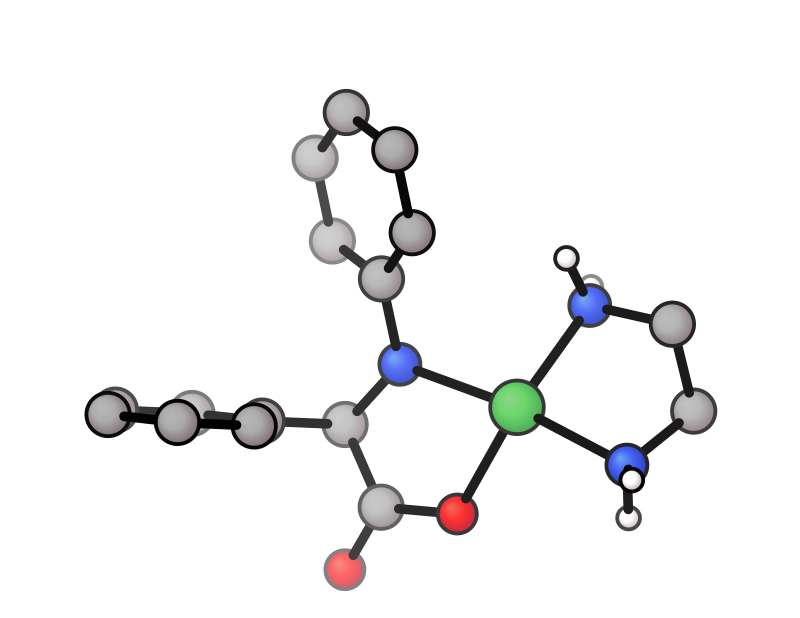

  [0] square_planar    O2 C8 N4 N7                (achiral)


rxembed | embed[square_planar: O2 C8 N4 N7]: 1 seeds
rxembed | minimize: re-embedded to 3/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]CC[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1
 square_planar | O2 C8 N4 N7 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'C8': 2.13, 'N7': 2.06}  | geom.check: clean


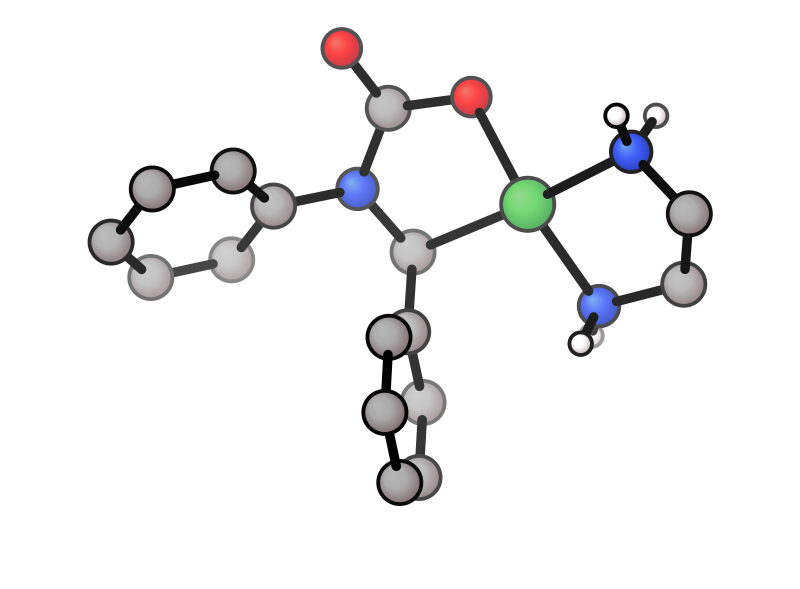

  [0] square_planar    N12 N9 O24 N34             (achiral)


rxembed | embed[square_planar: N12 N9 O24 N34]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)C(c1ccccc1)[N-]->4c1ccccc1)c1cccc4cccc3c14)C2
 square_planar | N12 N9 O24 N34 | achiral
  M-donor: {'N12': 2.07, 'O24': 2.02, 'N9': 2.07, 'N34': 2.07}  | geom.check: clean


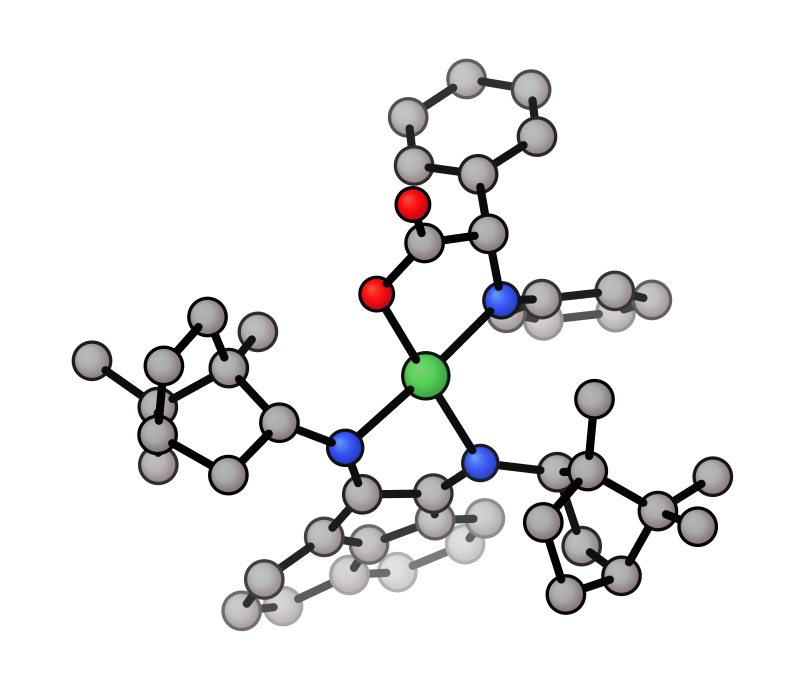

  [0] square_planar    N12 N9 O24 C34             (achiral)


rxembed | embed[square_planar: N12 N9 O24 C34]: 1 seeds
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1(C)C2CCC1(C)C([N]1=C3C(=[N](C4CC5CCC4(C)C5(C)C)->[Ni+2]<-14<-[O-]C(=O)N(c1ccccc1)[CH-]->4c1ccccc1)c1cccc4cccc3c14)C2
 square_planar | N12 N9 O24 C34 | achiral
  M-donor: {'N12': 2.07, 'O24': 2.01, 'N9': 2.07, 'C34': 2.13}  | geom.check: clean


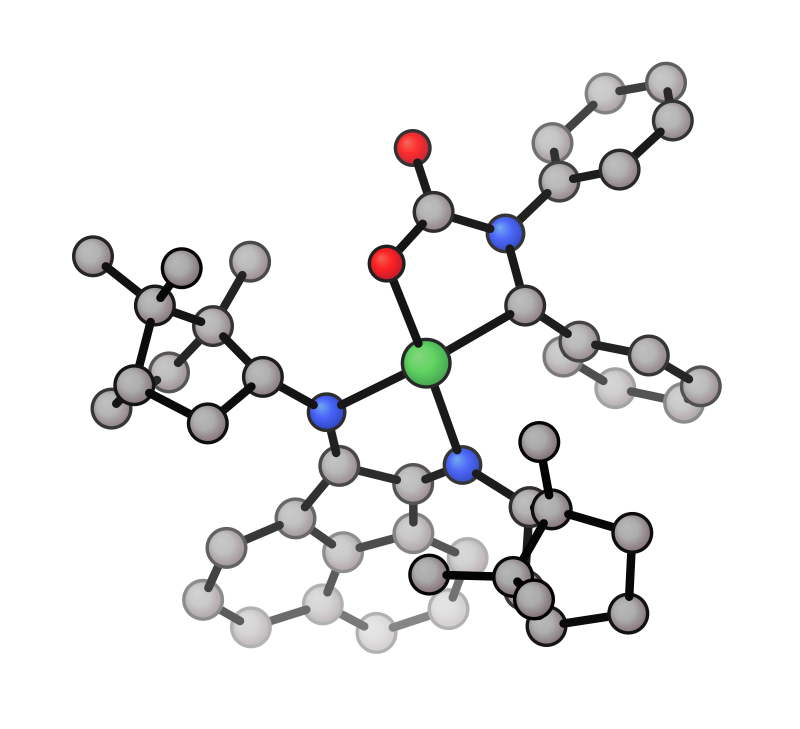

rxembed | embed[square_planar: N3 N22 O5 N15]: 1 seeds


  [0] square_planar    N3 N22 O5 N15              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43
 square_planar | N3 N22 O5 N15 | achiral
  M-donor: {'N3': 2.07, 'O5': 2.01, 'N22': 2.06, 'N15': 2.07}  | geom.check: clean


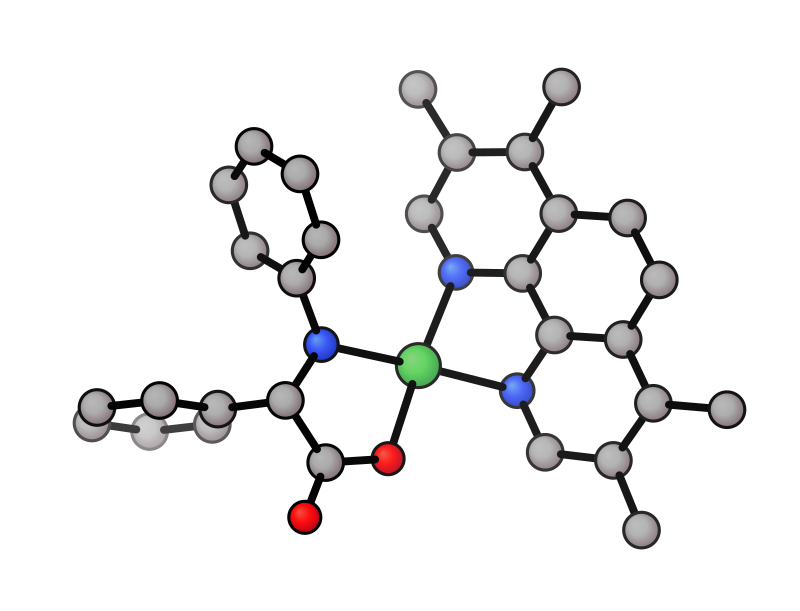

rxembed | embed[square_planar: N3 N22 O5 C15]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05


  [0] square_planar    N3 N22 O5 C15              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1c[n]2->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]3cc(C)c(C)c4ccc(c1C)c2c43
 square_planar | N3 N22 O5 C15 | achiral
  M-donor: {'N3': 2.01, 'O5': 1.96, 'N22': 2.01, 'C15': 2.06}  | geom.check: clean


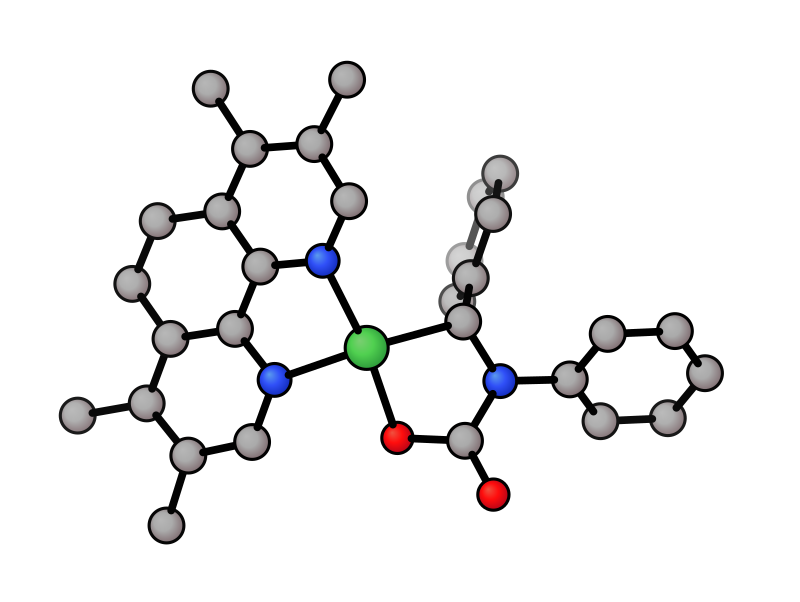

rxembed | embed[square_planar: O2 N4 P18 P37]: 1 seeds


  [0] square_planar    O2 N4 P18 P37              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N-](c3ccccc3)C1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1
 square_planar | O2 N4 P18 P37 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.07, 'P18': 2.24, 'P37': 2.24}  | geom.check: clean


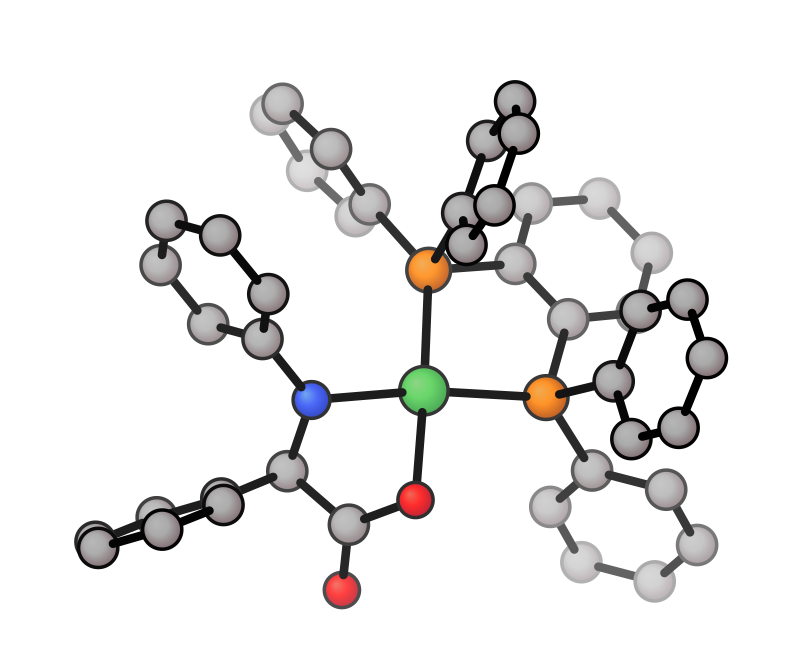

rxembed | embed[square_planar: O2 C4 P18 P37]: 1 seeds


  [0] square_planar    O2 C4 P18 P37              (achiral)


rxembed | minimize: re-embedded to 3/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[P](c1ccccc1)(c1ccccc1)c1ccccc1[P]->2(c1ccccc1)c1ccccc1
 square_planar | O2 C4 P18 P37 | achiral
  M-donor: {'O2': 2.01, 'C4': 2.13, 'P18': 2.24, 'P37': 2.24}  | geom.check: clean


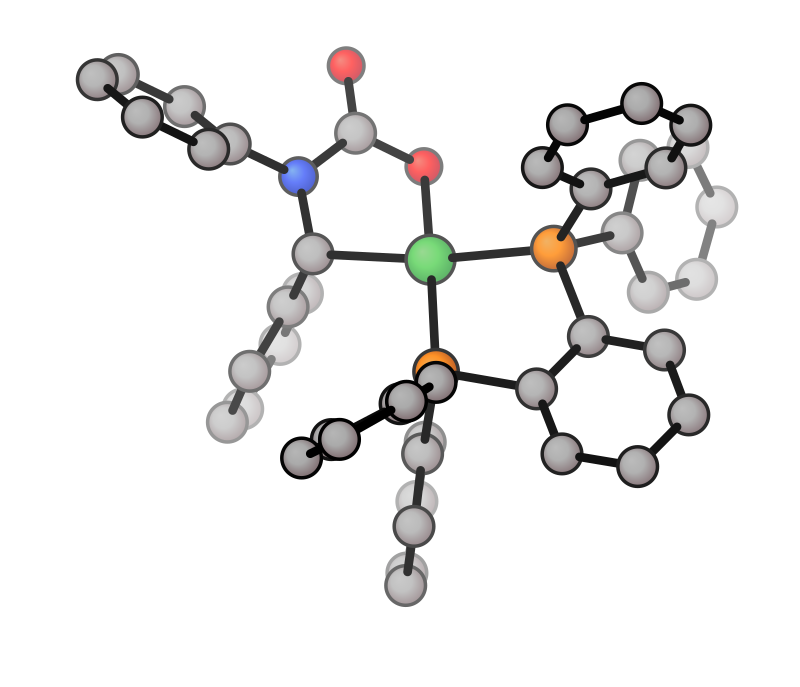

rxembed | embed[square_planar: N11 N30 O13 N23]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    N11 N30 O13 N23            (achiral)
embedding 
Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[n]2c1
 square_planar | N11 N30 O13 N23 | achiral
  M-donor: {'N11': 2.07, 'O13': 2.01, 'N30': 2.07, 'N23': 2.07}  | geom.check: clean


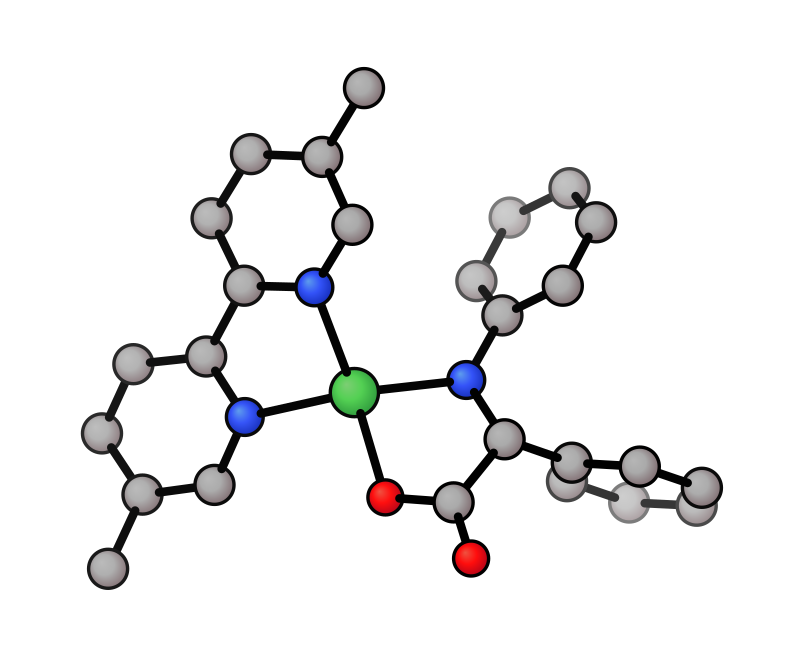

  [0] square_planar    N11 N30 O13 C23            (achiral)


rxembed | embed[square_planar: N11 N30 O13 C23]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1ccc2-c3ccc(C)c[n]3->[Ni+2]3(<-[O-]C(=O)N(c4ccccc4)[CH-]->3c3ccccc3)<-[n]2c1
 square_planar | N11 N30 O13 C23 | achiral
  M-donor: {'N11': 2.07, 'O13': 2.01, 'N30': 2.07, 'C23': 2.13}  | geom.check: clean


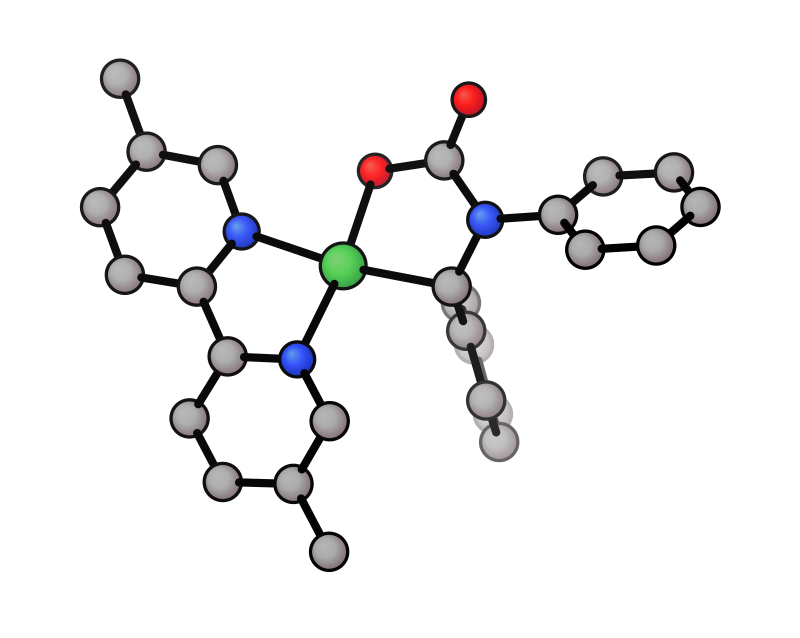

  [0] square_planar    N12 C35 O18 N28            (achiral)
  [1] square_planar    N12 C35 N28 O18            (achiral)


rxembed | embed[square_planar: N12 C35 O18 N28]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1
 square_planar | N12 C35 O18 N28 | achiral
  M-donor: {'N12': 2.07, 'O18': 2.01, 'C35': 2.12, 'N28': 2.07}  | geom.check: clean


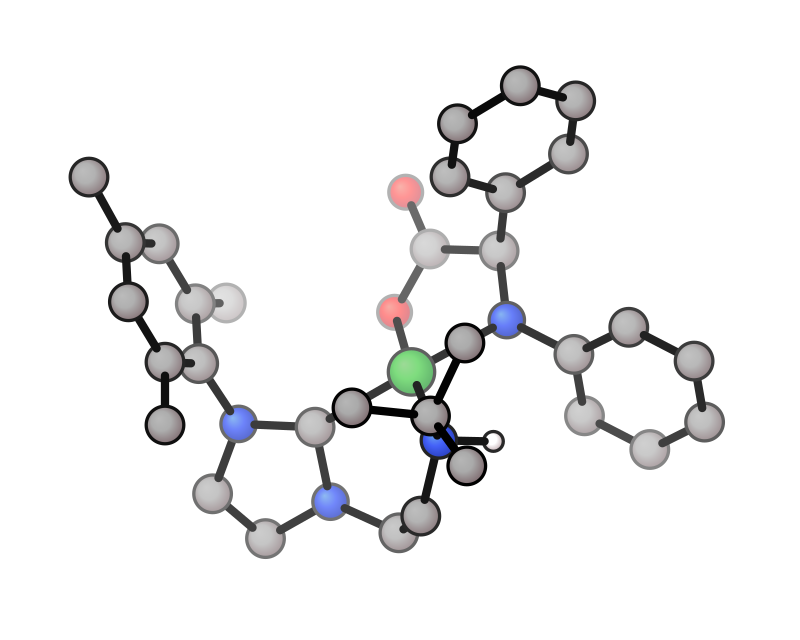

rxembed | embed[square_planar: N12 C35 N28 O18]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)C(c5ccccc5)[N-]->4c4ccccc4)<-[C]32)c(C)c1
 square_planar | N12 C35 N28 O18 | achiral
  M-donor: {'N12': 2.03, 'O18': 1.98, 'C35': 2.08, 'N28': 2.03}  | geom.check: clean


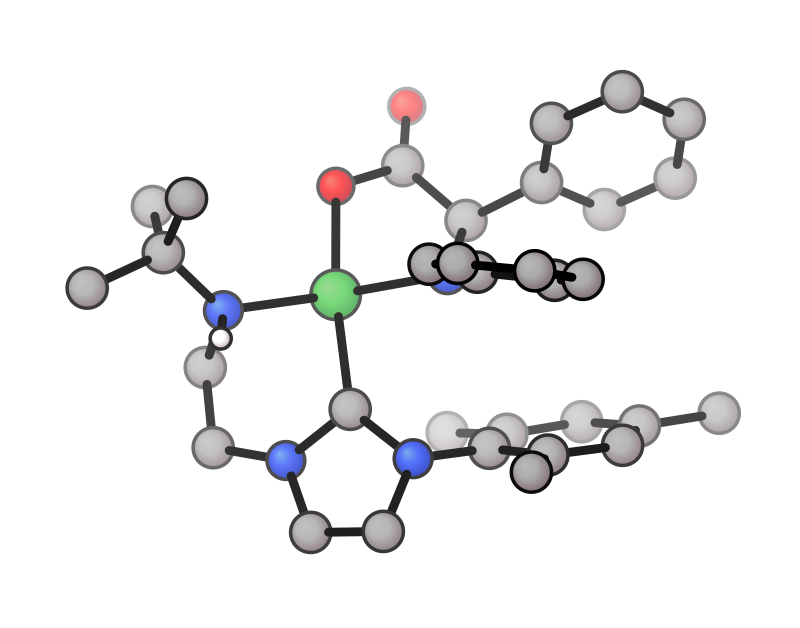

rxembed | embed[square_planar: N12 C35 O18 C28]: 1 seeds


  [0] square_planar    N12 C35 O18 C28            (achiral)
  [1] square_planar    N12 C35 C28 O18            (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1
 square_planar | N12 C35 O18 C28 | achiral
  M-donor: {'N12': 2.07, 'O18': 2.02, 'C35': 2.13, 'C28': 2.13}  | geom.check: clean


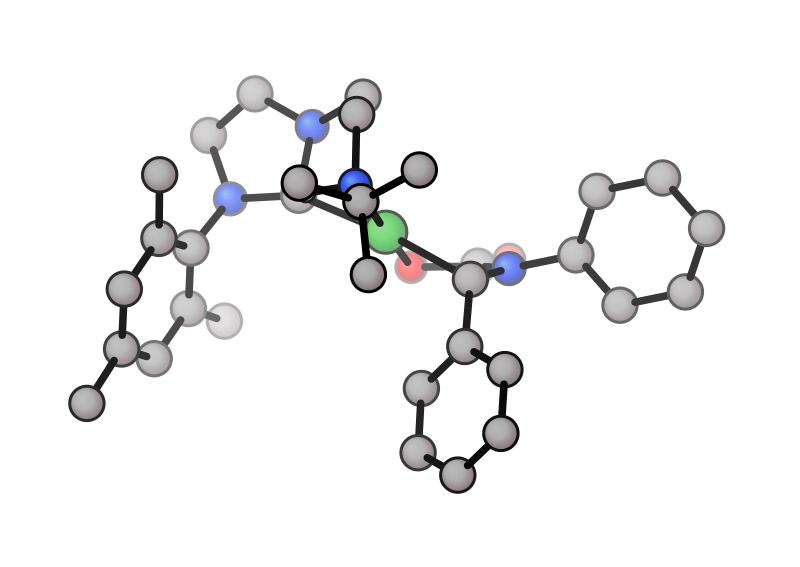

rxembed | embed[square_planar: N12 C35 C28 O18]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
Cc1cc(C)c(N2C=CN3CC[NH](C(C)(C)C)->[Ni+2]4(<-[O-]C(=O)N(c5ccccc5)[CH-]->4c4ccccc4)<-[C]32)c(C)c1
 square_planar | N12 C35 C28 O18 | achiral
  M-donor: {'N12': 2.07, 'O18': 2.01, 'C35': 2.12, 'C28': 2.13}  | geom.check: clean


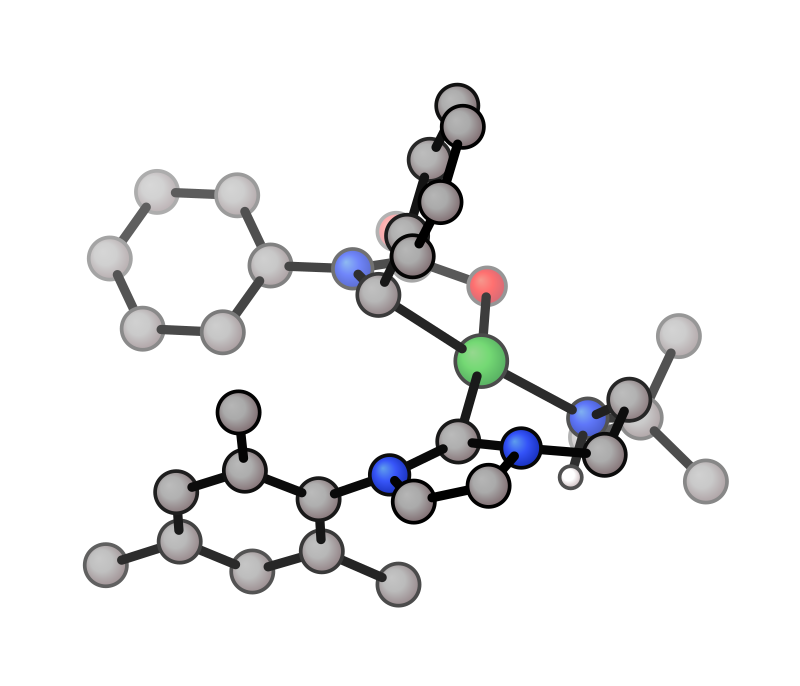

rxembed | embed[square_planar: O2 N12 O4 N11]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 N12 O4 N11              (achiral)
  [1] square_planar    O2 N12 N11 O4              (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N12 O4 N11 | achiral
  M-donor: {'O2': 2.01, 'O4': 2.01, 'N12': 2.06, 'N11': 2.06}  | geom.check: clean


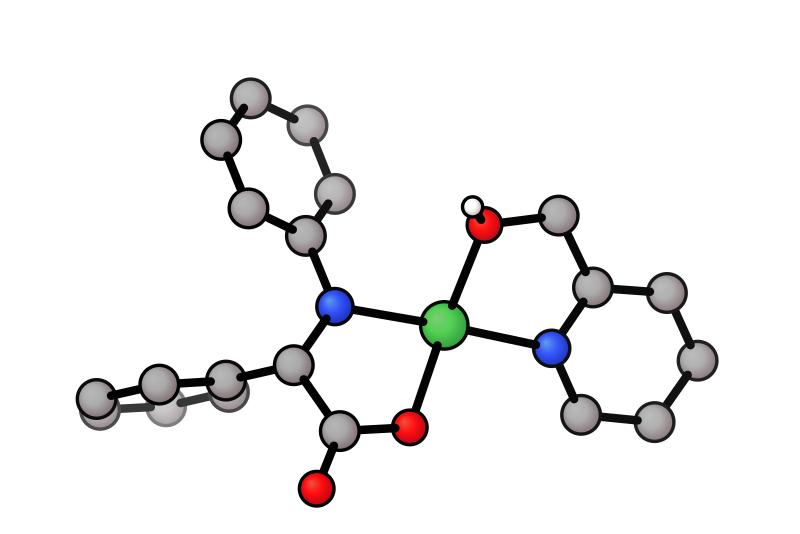

rxembed | embed[square_planar: O2 N12 N11 O4]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N12 N11 O4 | achiral
  M-donor: {'O2': 2.01, 'O4': 2.01, 'N12': 2.07, 'N11': 2.06}  | geom.check: clean


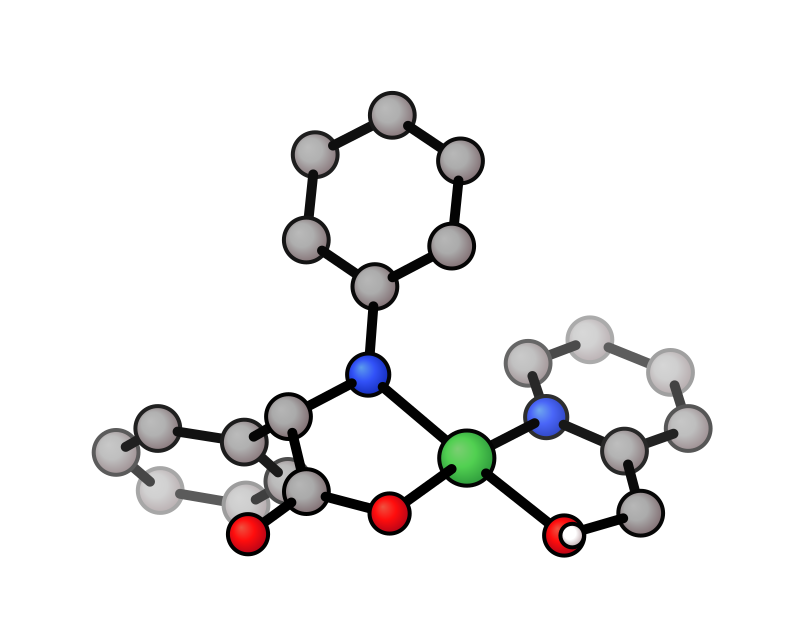

rxembed | embed[square_planar: O2 C12 O4 N11]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 C12 O4 N11              (achiral)
  [1] square_planar    O2 C12 N11 O4              (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1
 square_planar | O2 C12 O4 N11 | achiral
  M-donor: {'O2': 1.98, 'O4': 1.98, 'C12': 2.08, 'N11': 2.03}  | geom.check: clean


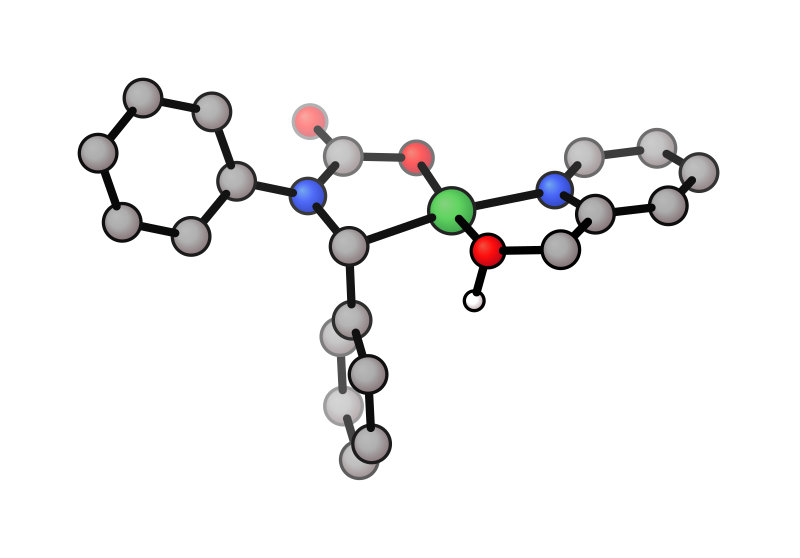

rxembed | embed[square_planar: O2 C12 N11 O4]: 1 seeds
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[OH]Cc3cccc[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1
 square_planar | O2 C12 N11 O4 | achiral
  M-donor: {'O2': 2.01, 'O4': 2.01, 'C12': 2.13, 'N11': 2.07}  | geom.check: clean


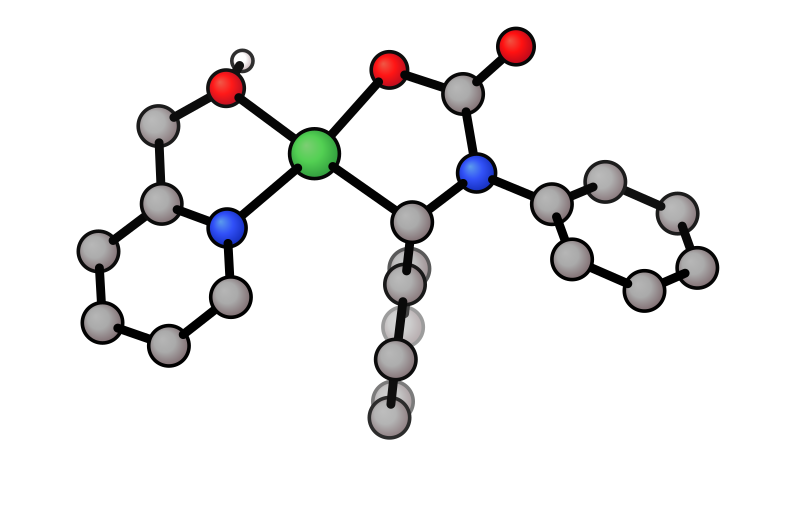

rxembed | embed[square_planar: O2 N12 N4 N11]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 N12 N4 N11              (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N12 N4 N11 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'N12': 2.06, 'N11': 2.06}  | geom.check: clean


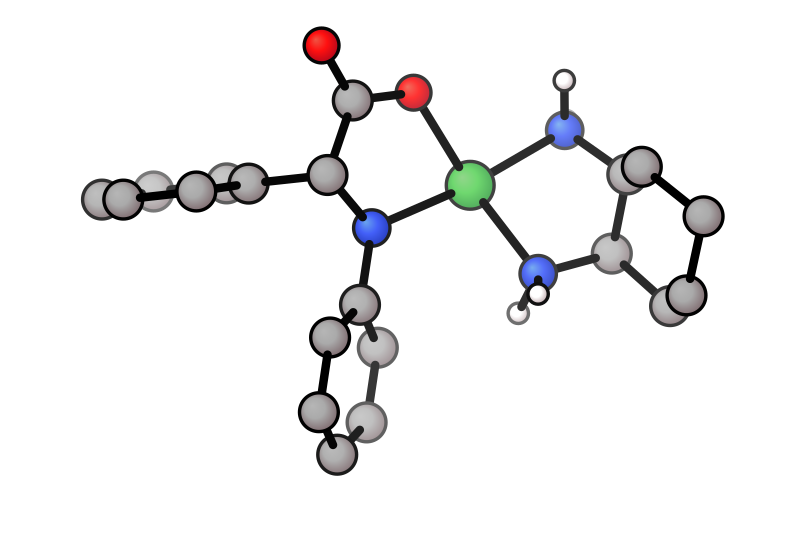

  [0] square_planar    O2 C12 N4 N11              (achiral)


rxembed | embed[square_planar: O2 C12 N4 N11]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]C3CCCCC3[NH2]->2)<-[CH-](c2ccccc2)N1c1ccccc1
 square_planar | O2 C12 N4 N11 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'C12': 2.13, 'N11': 2.06}  | geom.check: clean


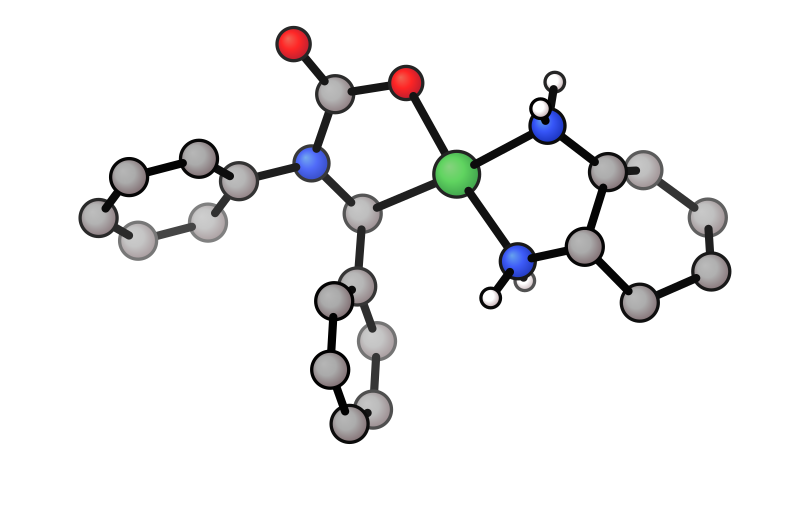

  [0] square_planar    P12 P43 O26 N36            (achiral)


rxembed | embed[square_planar: P12 P43 O26 N36]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1
 square_planar | P12 P43 O26 N36 | achiral
  M-donor: {'P12': 2.19, 'O26': 1.98, 'P43': 2.19, 'N36': 2.03}  | geom.check: clean


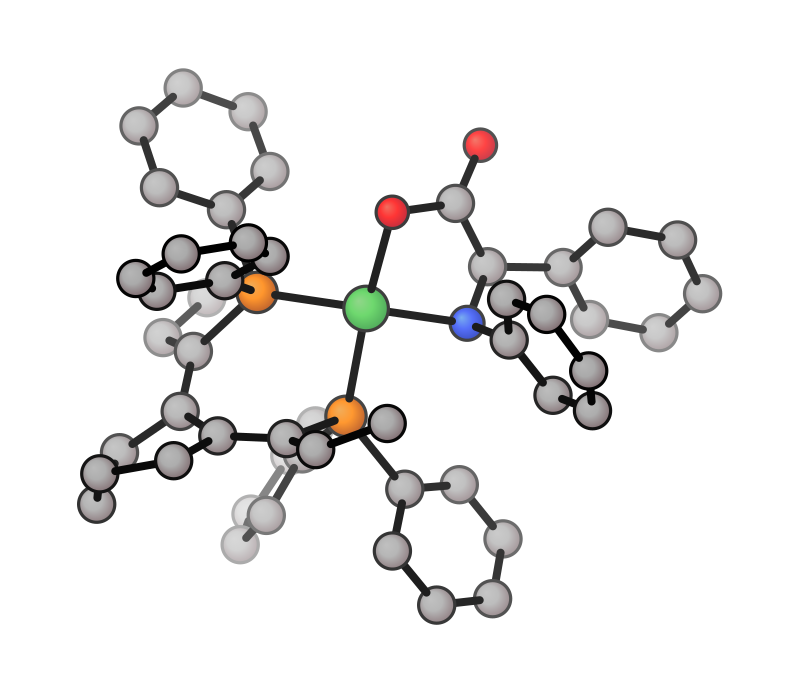

  [0] square_planar    P12 P43 O26 C36            (achiral)


rxembed | embed[square_planar: P12 P43 O26 C36]: 1 seeds
rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCC1=C2CCCCC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1
 square_planar | P12 P43 O26 C36 | achiral
  M-donor: {'P12': 2.19, 'O26': 1.98, 'P43': 2.19, 'C36': 2.08}  | geom.check: clean


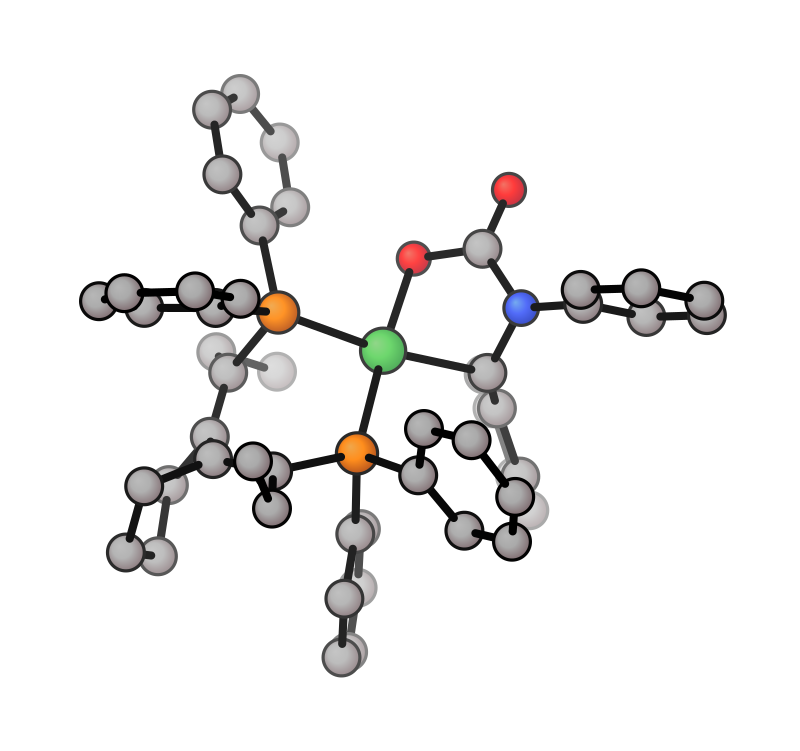

  [0] square_planar    P22 P53 O36 N46            (achiral)


rxembed | embed[square_planar: P22 P53 O36 N46]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1
 square_planar | P22 P53 O36 N46 | achiral
  M-donor: {'P22': 2.24, 'O36': 2.01, 'P53': 2.24, 'N46': 2.07}  | geom.check: clean


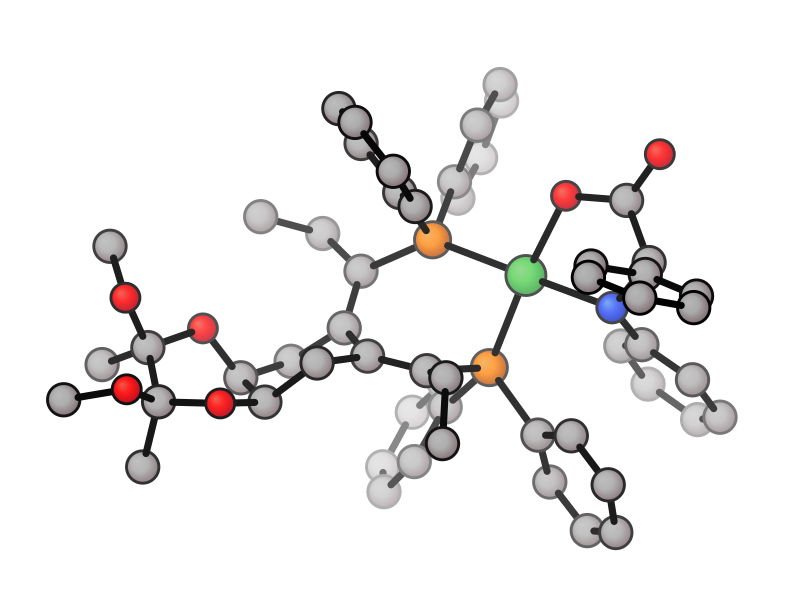

  [0] square_planar    P22 P53 O36 C46            (achiral)


rxembed | embed[square_planar: P22 P53 O36 C46]: 1 seeds
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CCC1=C2CC3OC(C)(OC)C(C)(OC)OC3CC2=C(CC)[P](c2ccccc2)(c2ccccc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[P]1(c1ccccc1)c1ccccc1
 square_planar | P22 P53 O36 C46 | achiral
  M-donor: {'P22': 2.24, 'O36': 2.01, 'P53': 2.24, 'C46': 2.13}  | geom.check: clean


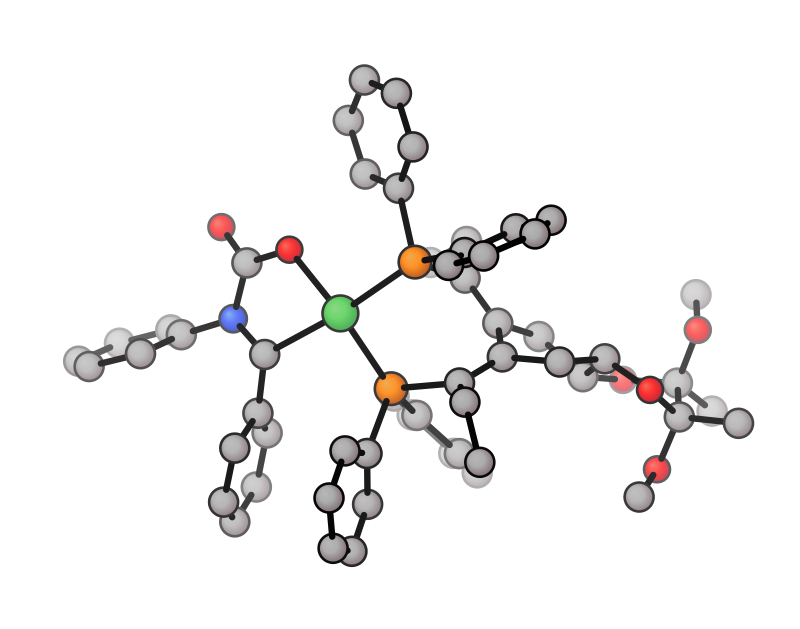

rxembed | embed[square_planar: O2 N12 N4 N11]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


  [0] square_planar    O2 N12 N4 N11              (achiral)
embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N12 N4 N11 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'N12': 2.07, 'N11': 2.06}  | geom.check: clean


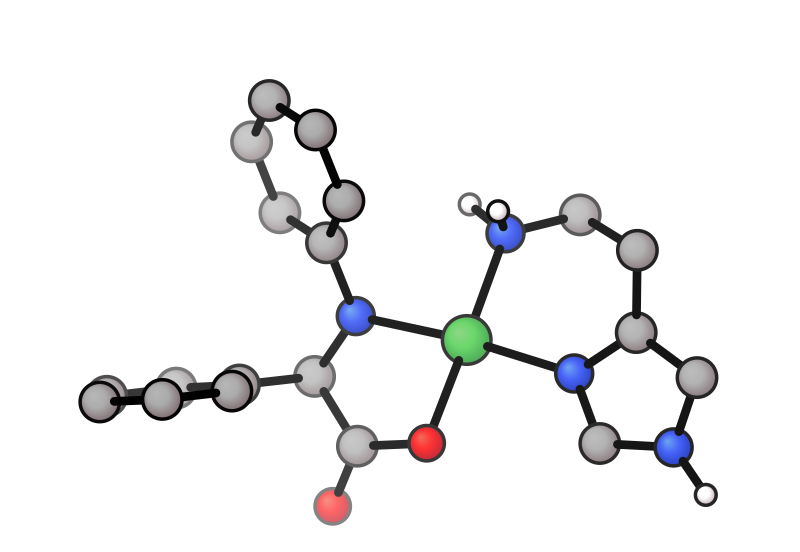

rxembed | embed[square_planar: O2 C12 N4 N11]: 1 seeds


  [0] square_planar    O2 C12 N4 N11              (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 1e+05
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 1 kept
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[NH2]CCc3c[nH]c[n]->23)<-[CH-](c2ccccc2)N1c1ccccc1
 square_planar | O2 C12 N4 N11 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.06, 'C12': 2.13, 'N11': 2.06}  | geom.check: clean


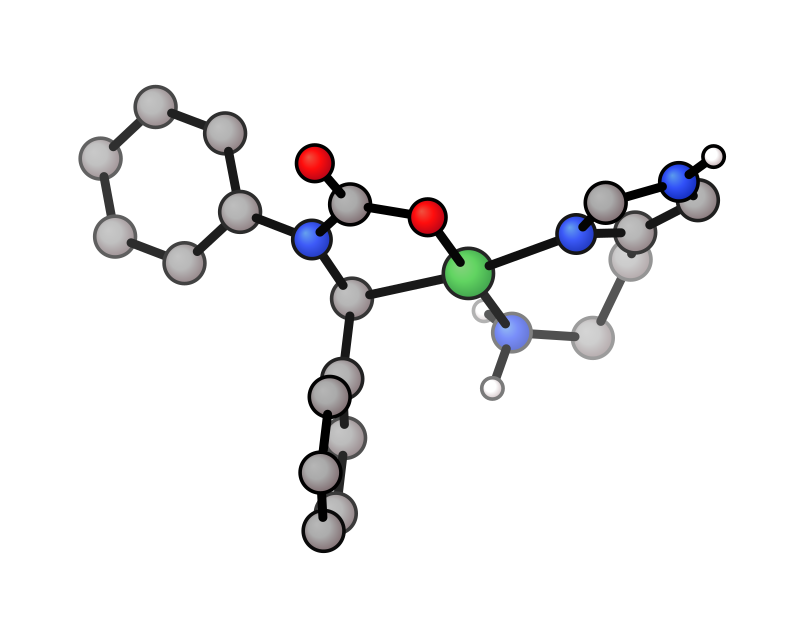

rxembed | embed[square_planar: N4 N30 O13 N23]: 1 seeds


  [0] square_planar    N4 N30 O13 N23             (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1[O]
 square_planar | N4 N30 O13 N23 | achiral
  M-donor: {'N4': 2.07, 'O13': 2.01, 'N30': 2.06, 'N23': 2.07}  | geom.check: clean


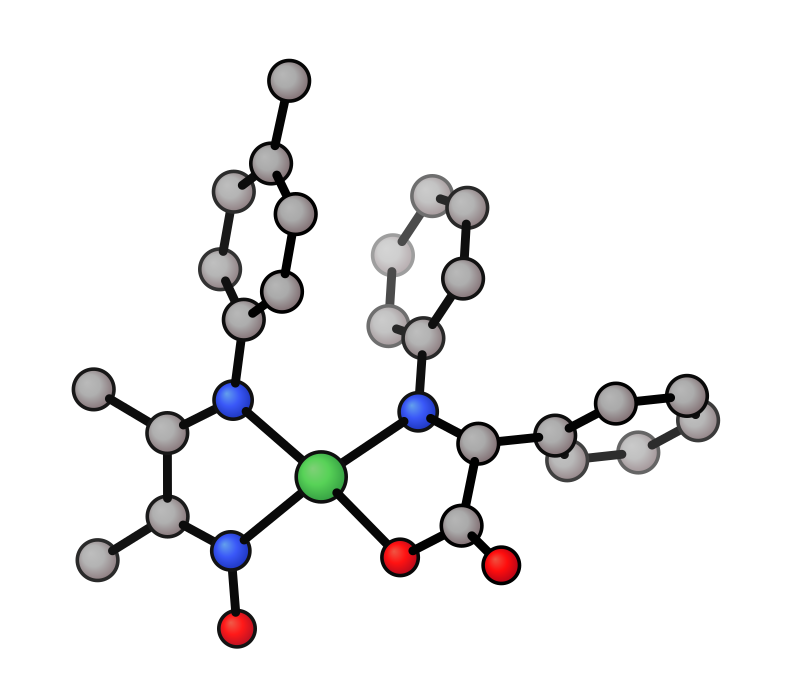

rxembed | embed[square_planar: N4 N30 O13 C23]: 1 seeds


  [0] square_planar    N4 N30 O13 C23             (achiral)


rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


embedding 
CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1[O]
 square_planar | N4 N30 O13 C23 | achiral
  M-donor: {'N4': 2.07, 'O13': 2.01, 'N30': 2.06, 'C23': 2.13}  | geom.check: clean


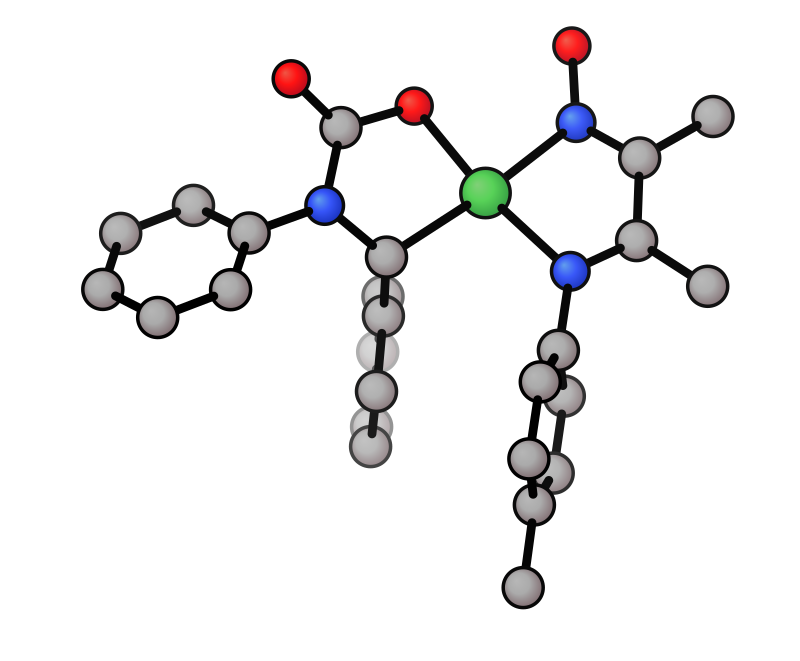

rxembed | embed[square_planar: N4 N30 O13 N23]: 1 seeds
rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 0 kept


  [0] square_planar    N4 N30 O13 N23             (achiral)


rxembed | minimize: dropped 1 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 2 kept
rxembed | minimize: re-embedded to 2/1 clean geometries


embedding 
CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)C(c3ccccc3)[N-]->2c2ccccc2)<-[N]=1O
 square_planar | N4 N30 O13 N23 | achiral
  M-donor: {'N4': 2.07, 'O13': 2.01, 'N30': 2.07, 'N23': 2.07}  | geom.check: clean


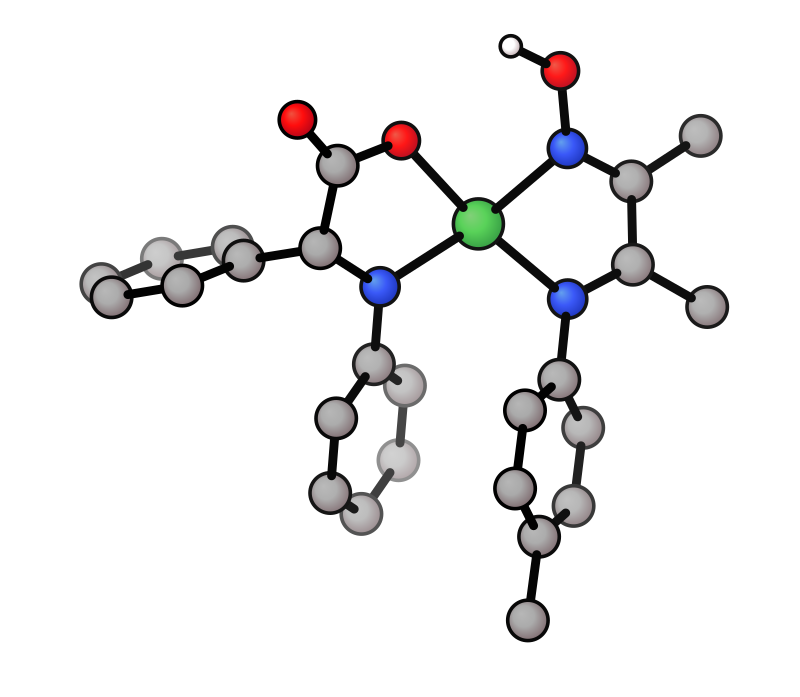

rxembed | embed[square_planar: N4 N30 O13 C23]: 1 seeds


  [0] square_planar    N4 N30 O13 C23             (achiral)


rxembed | minimize: soft relax tore the coordination sphere; escalated distance_fc to 3e+04
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
CC1C(C)=[N](c2ccc(C)cc2)->[Ni+2]2(<-[O-]C(=O)N(c3ccccc3)[CH-]->2c2ccccc2)<-[N]=1O
 square_planar | N4 N30 O13 C23 | achiral
  M-donor: {'N4': 2.03, 'O13': 1.98, 'N30': 2.03, 'C23': 2.08}  | geom.check: clean


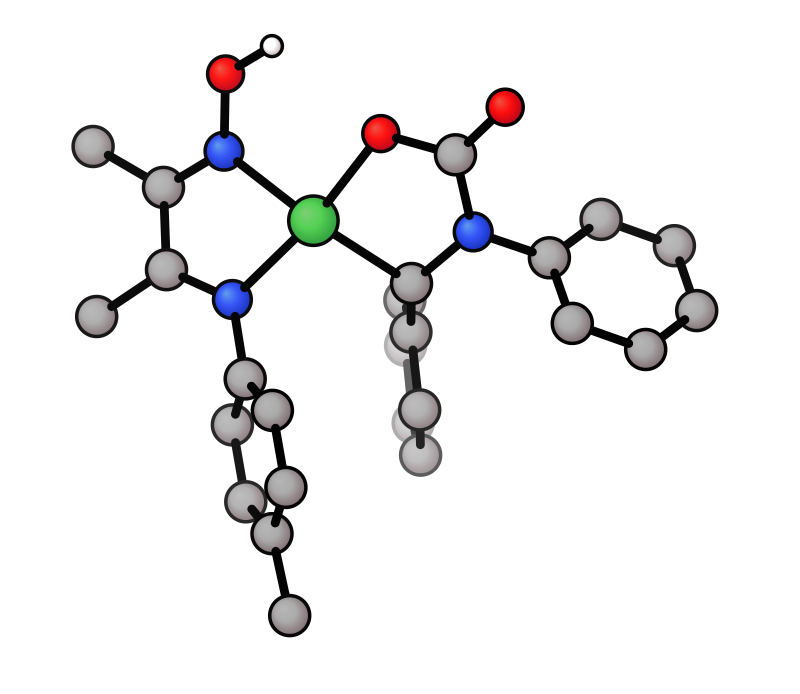

rxembed | embed[square_planar: O2 N38 N4 N7]: 1 seeds


  [0] square_planar    O2 N38 N4 N7               (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[N](=C3C(=[N]->2c2cccc4ccccc24)c2cccc4cccc3c24)c2cccc3ccccc23)<-[N-](c2ccccc2)C1c1ccccc1
 square_planar | O2 N38 N4 N7 | achiral
  M-donor: {'O2': 2.01, 'N4': 2.07, 'N38': 2.07, 'N7': 2.07}  | geom.check: clean


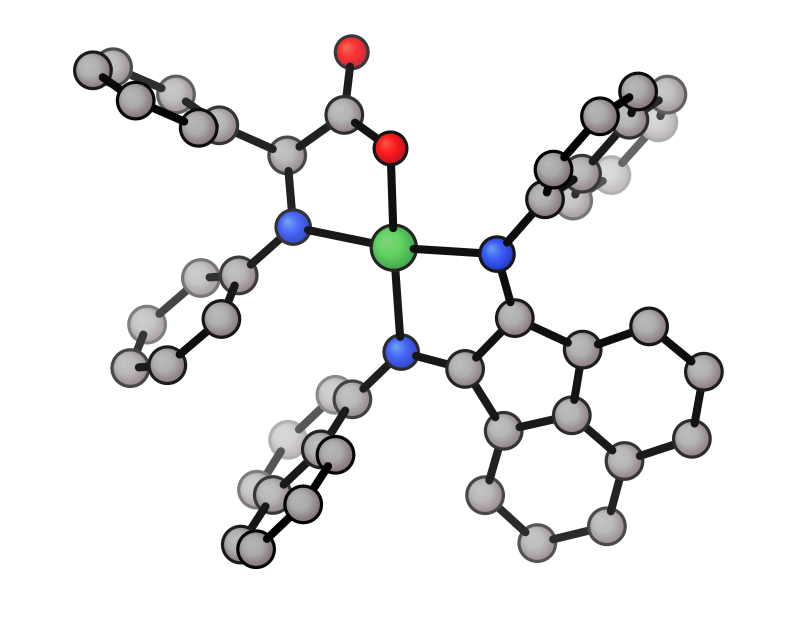

  [0] square_planar    O2 C4 N18 N21              (achiral)


rxembed | embed[square_planar: O2 C4 N18 N21]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
O=C1[O-]->[Ni+2]2(<-[CH-](c3ccccc3)N1c1ccccc1)<-[N](=C1C(=[N]->2c2cccc3ccccc23)c2cccc3cccc1c23)c1cccc2ccccc12
 square_planar | O2 C4 N18 N21 | achiral
  M-donor: {'O2': 2.01, 'C4': 2.13, 'N18': 2.07, 'N21': 2.07}  | geom.check: clean


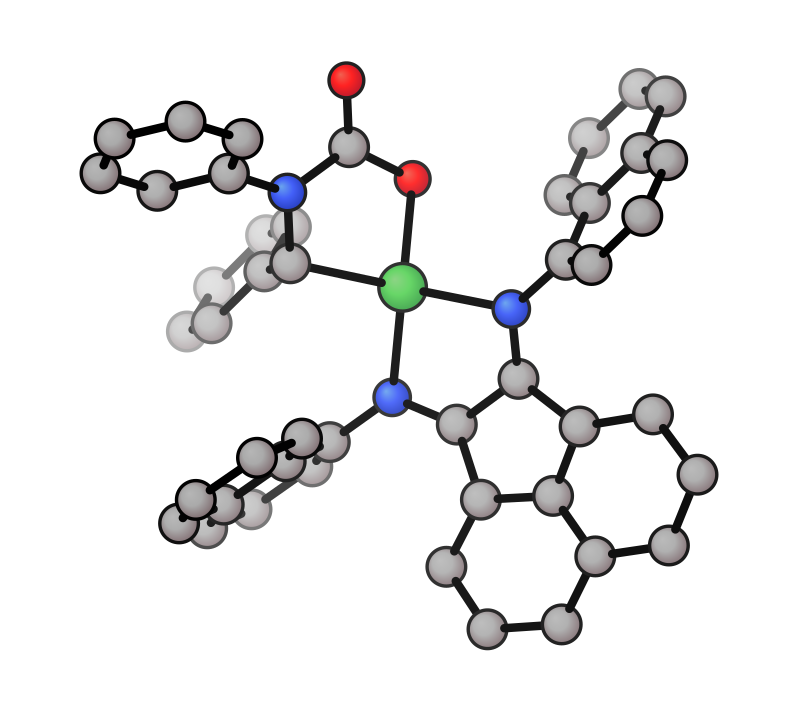

rxembed | embed[square_planar: N9 N6 O19 N29]: 1 seeds


  [0] square_planar    N9 N6 O19 N29              (achiral)


rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)C(c2ccccc2)[N-]->4c2ccccc2)c2cccc4cccc3c24)cc1
 square_planar | N9 N6 O19 N29 | achiral
  M-donor: {'N9': 2.07, 'O19': 2.01, 'N6': 2.07, 'N29': 2.07}  | geom.check: clean


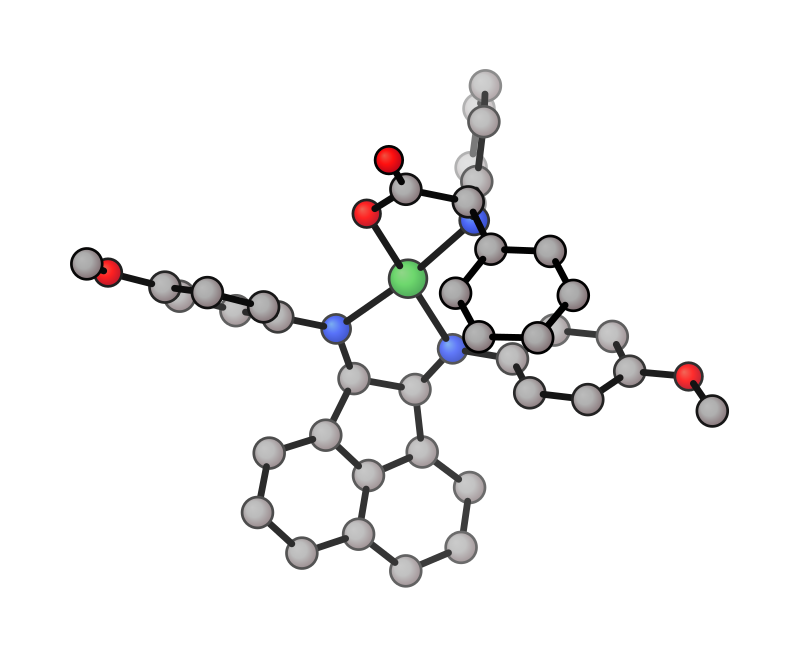

  [0] square_planar    N9 N6 O19 C29              (achiral)


rxembed | embed[square_planar: N9 N6 O19 C29]: 1 seeds
rxembed | minimize: re-embedded to 1/1 clean geometries


embedding 
COc1ccc([N]2=C3C(=[N](c4ccc(OC)cc4)->[Ni+2]<-24<-[O-]C(=O)N(c2ccccc2)[CH-]->4c2ccccc2)c2cccc4cccc3c24)cc1
 square_planar | N9 N6 O19 C29 | achiral
  M-donor: {'N9': 2.07, 'O19': 2.01, 'N6': 2.07, 'C29': 2.13}  | geom.check: clean


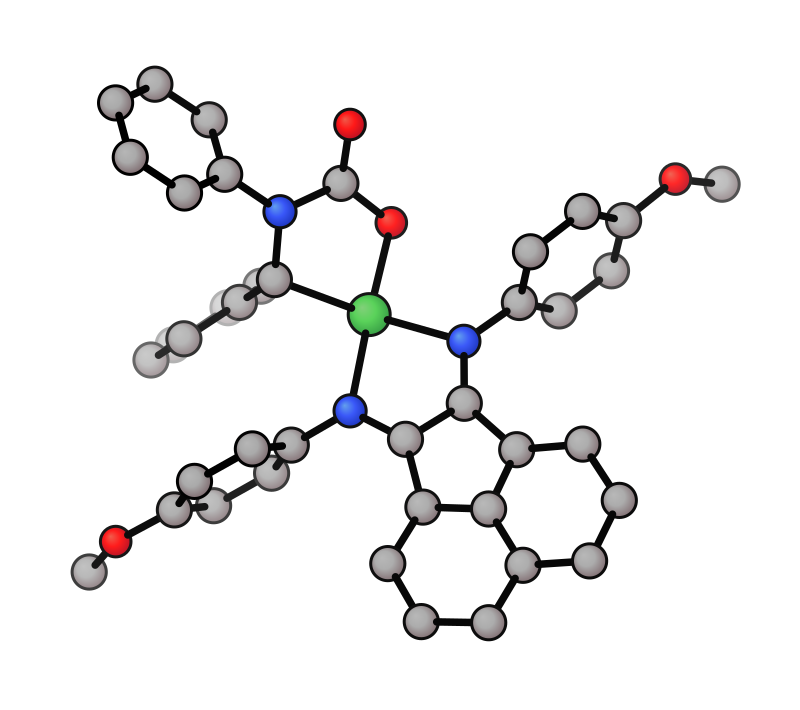

In [4]:
for smi_pair in smi_pairs:
    for smi in smi_pair:
        en = rx.metal(smi, "square_planar")
        en.summary()
        for iso in en:
            ens = rx.embed(iso, n=1).minimize()
            try:
                if not ens.n:
                    print(f"embedding \n{smi}\n {iso.summary()}\n  (no conformer embedded)")
                    continue
                c = ens.mol.GetConformer(ens.ids[0])
                # sanity check: the M-donor bond lengths + the whole-molecule gate. NB a good M-donor set +
                # bonding_ok is NOT sufficient — the periphery (substituent orientation, planarity) can still be
                # bad; only geom.check catches that, which is why it's the real acceptance test.
                mdist = {
                    f"{ens.mol.GetAtomWithIdx(d).GetSymbol()}{d}": round(T.GetBondLength(c, iso.metal, d), 2)
                    for d in iso.donors
                }
                gate = "clean" if rx.geometry.check(ens.mol, ens.ids[0]).ok() else "FLAGGED"
                print(f"embedding \n{smi}\n {iso.summary()}\n  M-donor: {mdist}  | geom.check: {gate}")
                display(xyzrender.render(xyz(ens), no_hy=True, bo=False))  # each embedded isomer
            except Exception as e:
                print("  error", e)

## Full pipeline on one complex

One representative catalyst — a flexible benzyl-imine amidate — through the whole chain with the real inline
API: **embed a conformer set → view the ensemble → Monte-Carlo search around several seeds → prune duplicates
→ inspect the conformer diversity** at each stage. `landscape()` also draws the pruned-away duplicates faded,
so you see exactly what the cleanup collapsed.


  [0] square_planar    P7 P2 O13 N23              (achiral)


rxembed | embed[square_planar: P7 P2 O13 N23]: 25 seeds
rxembed | minimize: dropped 4 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 21 kept
rxembed | minimize: re-embedded to 27/25 clean geometries


embed(n=25) -> minimize: 25 conformers


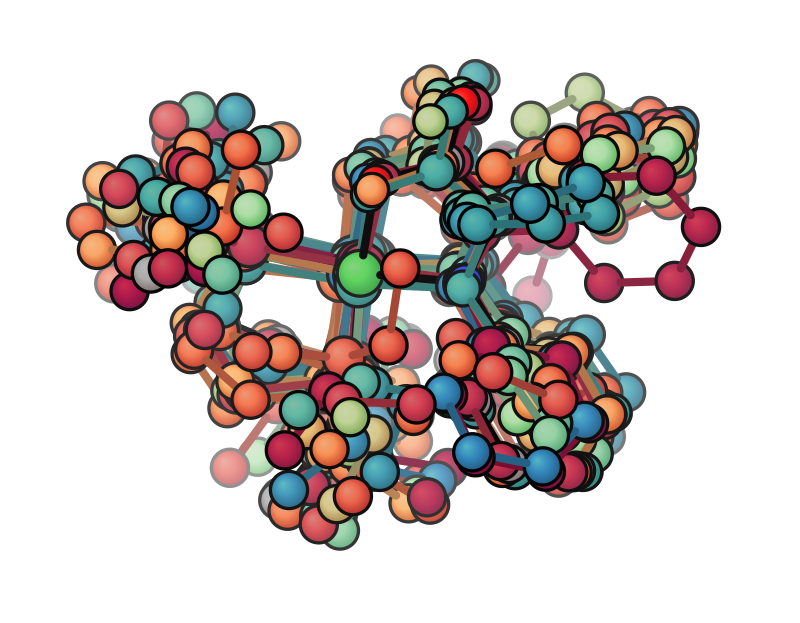

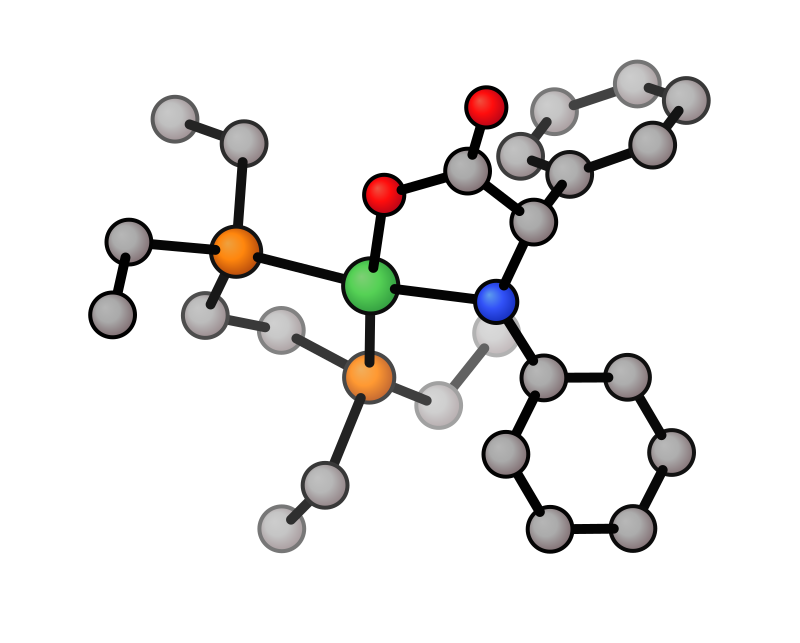

Exception ignored on calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7fed28d553a0>:
Traceback (most recent call last):
  File "/home/ali/Documents/Codes/rxembed/.venv/lib/python3.13/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/ali/Documents/Codes/rxembed/.venv/lib/python3.13/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/ali/Documents/Codes/rxembed/.venv/lib/python3.13/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/home/ali/bin/miniconda3/lib/python3.13/ctypes/__init__.py", line 361, in __init__
    self._handle = self._load_library(name, mode, handle, winmode)
  File "/home/ali/bin/miniconda3/lib/python3.13/ctypes/__init__.py", line 401, in _load_library
    r

<Axes: xlabel='TSNE 1', ylabel='TSNE 2'>

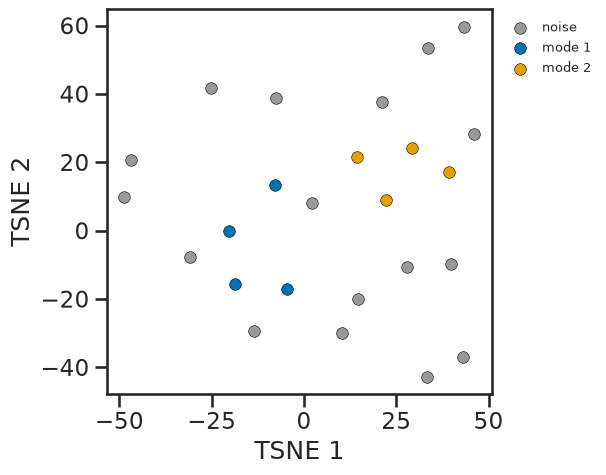

In [5]:
pipe_smi = "CC[P]1(CC)CC[P](CC)(CC)->[Ni+2]<-12<-[O-]C(=O)C(c1ccccc1)[N-]->2c1ccccc1"
iso = rx.metal(pipe_smi, "square_planar")
iso.summary()

ens = rx.embed(iso[0], n=25).minimize()  # 25 seeds -> edited-bounds embed -> restrained relax
print(f"embed(n=25) -> minimize: {ens.n} conformers")
display(
    xyzrender.render(xyzrender.load(mxyz(ens.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False)
)  # all conformers, aligned
display(xyzrender.render(xyzrender.load(mxyz(ens.align())), no_hy=True, bo=False))  # all conformers, aligned
ens.landscape(method="tsne")  # conformer diversity of the raw embed set

rxembed | embed[square_planar: P7 P2 O13 N23]: 10 seeds
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 8 kept
rxembed | minimize: re-embedded to 12/10 clean geometries
rxembed | mc: 7 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +68 (openconf 'transition_metal', pose-constrained around seeds; total 78)
rxembed | minimize: dropped 2 conformer(s) with a broken bond, out-of-plane coordination sphere, or non-physical relax energy -> 76 kept


embed(n=10) -> minimize -> mc(transition_metal): 76 conformers


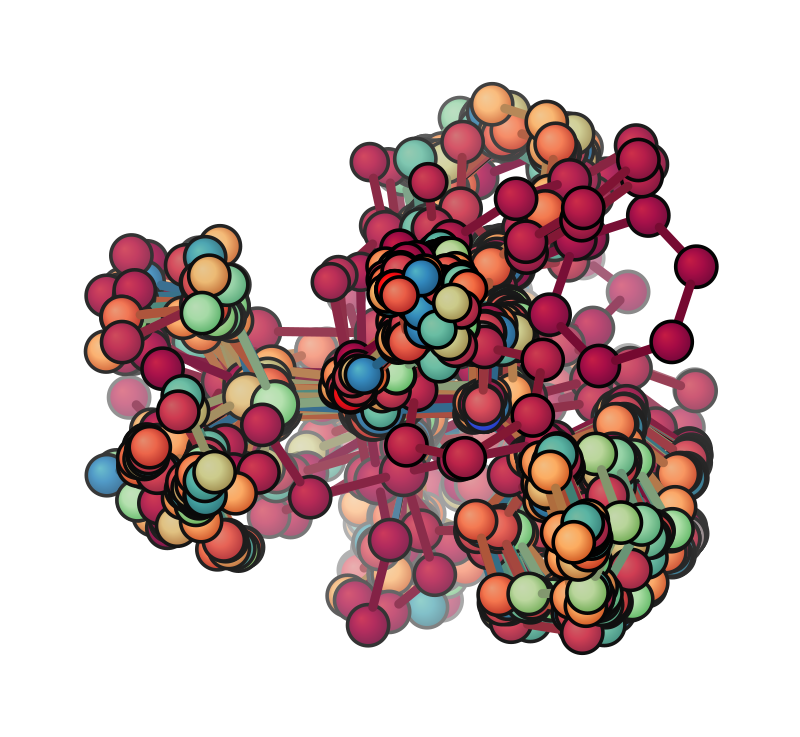

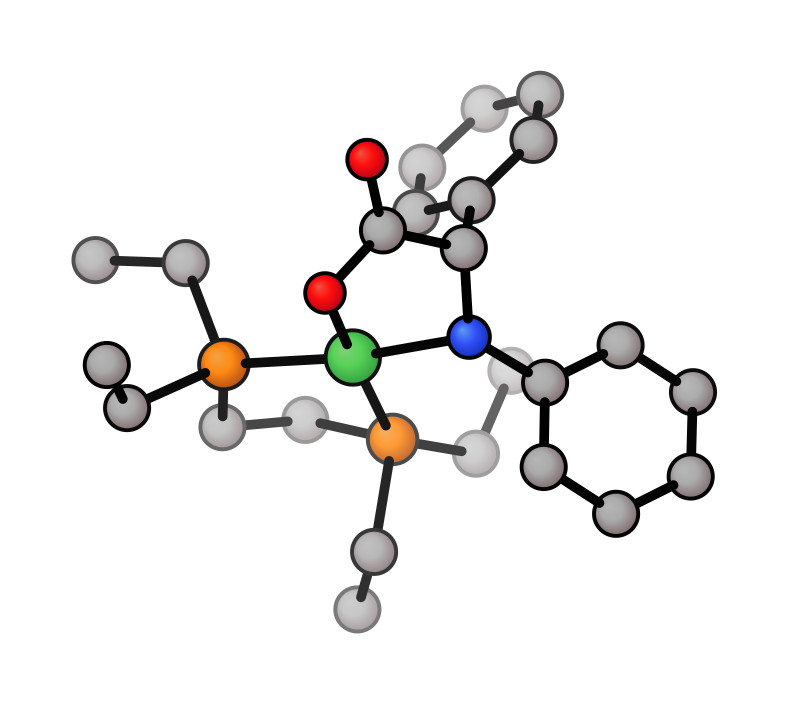

<Axes: xlabel='PCA 1', ylabel='PCA 2'>

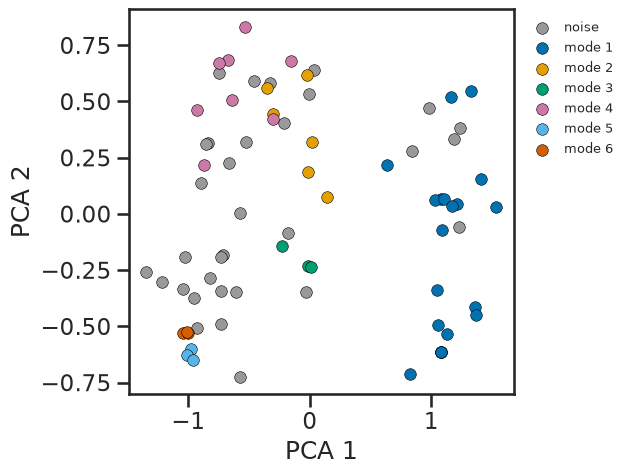

In [6]:
searched = (
    rx.embed(iso[0], n=10).minimize().mc(preset="transition_metal").minimize()
)  # 5 seeds -> MC torsional search around each
print(f"embed(n=10) -> minimize -> mc(transition_metal): {searched.n} conformers")
display(
    xyzrender.render(
        xyzrender.load(mxyz(searched.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False
    )
)

display(xyzrender.render(xyzrender.load(mxyz(searched)), no_hy=True, bo=False))
searched.landscape()

rxembed | prune[rmsd]: 76 -> 48  (merged 28 near-duplicates; see .duplicates())


prune: 76 -> 48 conformers  (28 duplicates removed)


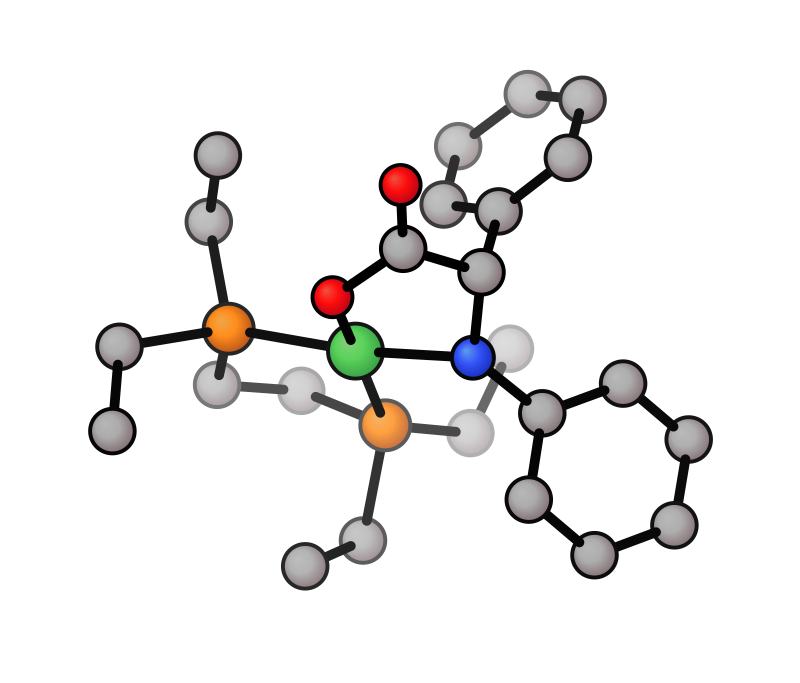

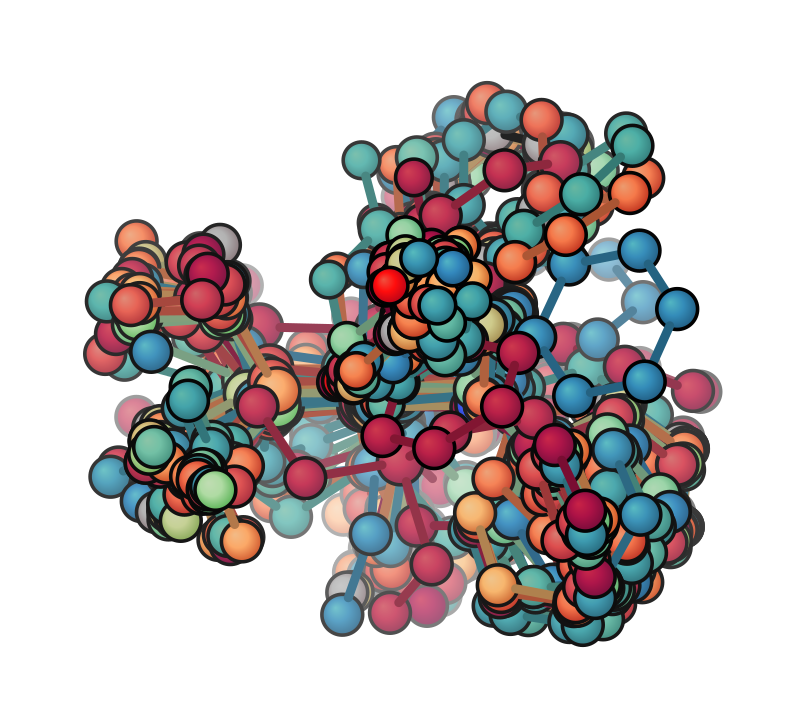

<Axes: xlabel='PCA 1', ylabel='PCA 2'>

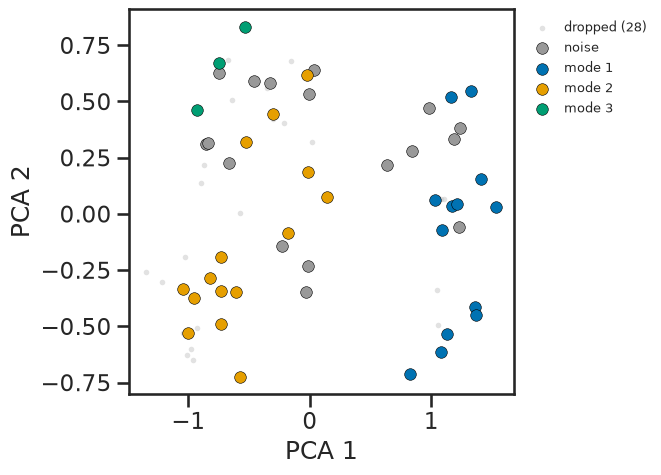

In [7]:
before = searched.n
searched.prune()  # dedup: moment-of-inertia / RMSD / descriptor prune
print(f"prune: {before} -> {searched.n} conformers  ({before - searched.n} duplicates removed)")
display(xyzrender.render(mxyz(searched.align()), no_hy=True, bo=False))
display(
    xyzrender.render(
        xyzrender.load(mxyz(searched.align()), ensemble=True, ensemble_color="spectral"), no_hy=True, bo=False
    )
)
searched.landscape()  # kept representatives (solid) + the pruned-away duplicates (faded), one space